In [1]:
import numpy as np
import re
import pandas as pd
from matplotlib import pyplot as plt
from sklearn.impute import SimpleImputer
from sklearn.model_selection import train_test_split
from sklearn.svm import SVC
from sklearn.ensemble import RandomForestRegressor
from sklearn.ensemble import RandomForestClassifier
from __future__ import unicode_literals
from collections import Counter
from math import *
from sklearn.model_selection import cross_validate
from sklearn.model_selection import cross_val_score
from imblearn.over_sampling import SMOTE
from imblearn.combine import SMOTEENN
from sklearn.linear_model import LinearRegression,Ridge,Lasso,RidgeCV
from sklearn.ensemble import RandomForestRegressor,BaggingRegressor,GradientBoostingRegressor,AdaBoostRegressor
from sklearn.svm import SVR
from sklearn.neighbors import KNeighborsRegressor
from sklearn.preprocessing import LabelEncoder
from sklearn.linear_model import ElasticNet
from sklearn.linear_model import LogisticRegression
from sklearn.neighbors import NearestCentroid
from sklearn.metrics import classification_report, f1_score,accuracy_score ,confusion_matrix
from sklearn.linear_model import LinearRegression
from sklearn.metrics import confusion_matrix
from collections import Counter
from sklearn.metrics import mean_squared_error
from sklearn.preprocessing import StandardScaler
from sklearn.metrics import r2_score
from sklearn.tree import DecisionTreeClassifier
from sklearn.tree import DecisionTreeRegressor
from sklearn.ensemble import IsolationForest
import matplotlib.gridspec as gridspec
from sklearn.impute import KNNImputer
import seaborn as sns
import warnings
from warnings import simplefilter
import ast
simplefilter(action='ignore', category=FutureWarning)
pd.options.mode.chained_assignment = None  # default='warn'
from warnings import simplefilter
# ignore all future warnings
simplefilter(action='ignore', category=FutureWarning)
pd.set_option('display.max_columns', None)
import warnings
with warnings.catch_warnings():
    warnings.simplefilter(action='ignore', category=pd.errors.PerformanceWarning)

In [2]:
dict_columns = ['belongs_to_collection', 'genres', 'production_companies',
                'production_countries', 'spoken_languages', 'Keywords', 'cast', 'crew']
def text_to_dict(df):
    for column in dict_columns:
        df[column] = df[column].apply(lambda x: {} if pd.isna(x) else ast.literal_eval(x) )
    return df

In [3]:
train_df = text_to_dict(pd.read_csv('../input/tmdb-box-office-prediction/train.csv'))
test_df = text_to_dict(pd.read_csv('../input/tmdb-box-office-prediction/test.csv'))

In [4]:
train_df.head()

,id,belongs_to_collection,budget,genres,homepage,imdb_id,original_language,original_title,overview,popularity,poster_path,production_companies,production_countries,release_date,runtime,spoken_languages,status,tagline,title,Keywords,cast,crew,revenue
0,1,"[{'id': 313576, 'name': 'Hot Tub Time Machine ...",14000000,"[{'id': 35, 'name': 'Comedy'}]",NaN,tt2637294,en,Hot Tub Time Machine 2,"When Lou, who has become the ""father of the In...",6.575393,/tQtWuwvMf0hCc2QR2tkolwl7c3c.jpg,"[{'name': 'Paramount Pictures', 'id': 4}, {'na...","[{'iso_3166_1': 'US', 'name': 'United States o...",2/20/15,93.0,"[{'iso_639_1': 'en', 'name': 'English'}]",Released,The Laws of Space and Time are About to be Vio...,Hot Tub Time Machine 2,"[{'id': 4379, 'name': 'time travel'}, {'id': 9...","[{'cast_id': 4, 'character': 'Lou', 'credit_id...","[{'credit_id': '59ac067c92514107af02c8c8', 'de...",12314651
1,2,"[{'id': 107674, 'name': 'The Princess Diaries ...",40000000,"[{'id': 35, 'name': 'Comedy'}, {'id': 18, 'nam...",NaN,tt0368933,en,The Princess Diaries 2: Royal Engagement,Mia Thermopolis is now a college graduate and ...,8.248895,/w9Z7A0GHEhIp7etpj0vyKOeU1Wx.jpg,"[{'name': 'Walt Disney Pictures', 'id': 2}]","[{'iso_3166_1': 'US', 'name': 'United States o...",8/6/04,113.0,"[{'iso_639_1': 'en', 'name': 'English'}]",Released,It can take a lifetime to find true love; she'...,The Princess Diaries 2: Royal Engagement,"[{'id': 2505, 'name': 'coronation'}, {'id': 42...","[{'cast_id': 1, 'character': 'Mia Thermopolis'...","[{'credit_id': '52fe43fe9251416c7502563d', 'de...",95149435
2,3,{},3300000,"[{'id': 18, 'name': 'Drama'}]",http://sonyclassics.com/whiplash/,tt2582802,en,Whiplash,"Under the direction of a ruthless instructor, ...",64.299990,/lIv1QinFqz4dlp5U4lQ6HaiskOZ.jpg,"[{'name': 'Bold Films', 'id': 2266}, {'name': ...","[{'iso_3166_1': 'US', 'name': 'United States o...",10/10/14,105.0,"[{'iso_639_1': 'en', 'name': 'English'}]",Released,The road to greatness can take you to the edge.,Whiplash,"[{'id': 1416, 'name': 'jazz'}, {'id': 1523, 'n...","[{'cast_id': 5, 'character': 'Andrew Neimann',...","[{'credit_id': '54d5356ec3a3683ba0000039', 'de...",13092000
3,4,{},1200000,"[{'id': 53, 'name': 'Thriller'}, {'id': 18, 'n...",http://kahaanithefilm.com/,tt1821480,hi,Kahaani,Vidya Bagchi (Vidya Balan) arrives in Kolkata ...,3.174936,/aTXRaPrWSinhcmCrcfJK17urp3F.jpg,{},"[{'iso_3166_1': 'IN', 'name': 'India'}]",3/9/12,122.0,"[{'iso_639_1': 'en', 'name': 'English'}, {'iso...",Released,NaN,Kahaani,"[{'id': 10092, 'name': 'mystery'}, {'id': 1054...","[{'cast_id': 1, 'character': 'Vidya Bagchi', '...","[{'credit_id': '52fe48779251416c9108d6eb', 'de...",16000000
4,5,{},0,"[{'id': 28, 'name': 'Action'}, {'id': 53, 'nam...",NaN,tt1380152,ko,마린보이,Marine Boy is the story of a former national s...,1.148070,/m22s7zvkVFDU9ir56PiiqIEWFdT.jpg,{},"[{'iso_3166_1': 'KR', 'name': 'South Korea'}]",2/5/09,118.0,"[{'iso_639_1': 'ko', 'name': '한국어/조선말'}]",Released,NaN,Marine Boy,{},"[{'cast_id': 3, 'character': 'Chun-soo', 'cred...","[{'credit_id': '52fe464b9251416c75073b43', 'de...",3923970


In [5]:
train_df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 3000 entries, 0 to 2999
Data columns (total 23 columns):
 #   Column                 Non-Null Count  Dtype  
---  ------                 --------------  -----  
 0   id                     3000 non-null   int64  
 1   belongs_to_collection  3000 non-null   object 
 2   budget                 3000 non-null   int64  
 3   genres                 3000 non-null   object 
 4   homepage               946 non-null    object 
 5   imdb_id                3000 non-null   object 
 6   original_language      3000 non-null   object 
 7   original_title         3000 non-null   object 
 8   overview               2992 non-null   object 
 9   popularity             3000 non-null   float64
 10  poster_path            2999 non-null   object 
 11  production_companies   3000 non-null   object 
 12  production_countries   3000 non-null   object 
 13  release_date           3000 non-null   object 
 14  runtime                2998 non-null   float64
 15  spok

In [6]:
train_df.isna().sum()

id                          0
belongs_to_collection       0
budget                      0
genres                      0
homepage                 2054
imdb_id                     0
original_language           0
original_title              0
overview                    8
popularity                  0
poster_path                 1
production_companies        0
production_countries        0
release_date                0
runtime                     2
spoken_languages            0
status                      0
tagline                   597
title                       0
Keywords                    0
cast                        0
crew                        0
revenue                     0
dtype: int64

In [7]:
train_df.shape[0]

3000

## belongs_to_collection

In [8]:
train_df[["belongs_to_collection","title"]].sample(10)

,belongs_to_collection,title
548,"[{'id': 426103, 'name': 'Ouija Collection', 'p...",Ouija: Origin of Evil
259,{},The Terrorist
571,"[{'id': 105625, 'name': 'House of 1000 Corpses...",House of 1000 Corpses
352,{},The Wild Life
2666,{},The Tree of Life
2935,{},The Stepford Wives
1330,{},Shoot the Moon
1014,{},Texas Killing Fields
805,{},Red Lights
1385,{},The Beaver


In [9]:
for index,row in train_df.iterrows():
    if row["belongs_to_collection"] != {}:
        for i in row["belongs_to_collection"]:
            train_df["belongs_to_collection"][index] = i["name"]
    else:
        title = row["title"]
        if (title.split()[0].isdigit()) and (len(title.split()) >= 1 ) :
            train_df["belongs_to_collection"][index] = (title.strip())+" Collection"
        else:
            regex = r"([a-zA-Z \d \, \[ \] \' \. \& \( \) \_ \! \? \x00-\x7F]*)"
            train_df["belongs_to_collection"][index] = ((re.findall(regex,title))[0]) + " Collection"

## budget                      

In [10]:
train_df.replace(0,train_df["budget"].mean(),inplace=True)
#####
test_df.replace(0,test_df["budget"].mean(),inplace=True)

In [11]:
train_df[train_df["budget"] == 0]

,id,belongs_to_collection,budget,genres,homepage,imdb_id,original_language,original_title,overview,popularity,poster_path,production_companies,production_countries,release_date,runtime,spoken_languages,status,tagline,title,Keywords,cast,crew,revenue


## genres

In [12]:
train_df["genres"] = train_df["genres"].apply(lambda x: train_df["genres"].mode()[0] if x=={} else x)
test_df["genres"] = test_df["genres"].apply(lambda x: test_df["genres"].mode()[0] if x=={} else x)

In [13]:
list_of_genres = list(train_df['genres'].apply(lambda x: [i['name'] for i in x] if x != {} else []).values)
train_df["genre_count"] = train_df["genres"].apply(lambda x: len(x))
train_df['all_genres'] = train_df['genres'].apply(lambda x: ' '.join(sorted([i['name'] for i in x])) if x != {} else '')
top_genres = [m[0] for m in Counter([i for j in list_of_genres for i in j]).most_common(15)]
for g in top_genres:
    train_df['genre_' + g] = train_df['all_genres'].apply(lambda x: 1 if g in x else 0)
test_df["genre_count"] = test_df["genres"].apply(lambda x: len(x))
test_df['all_genres'] = test_df['genres'].apply(lambda x: ' '.join(sorted([i['name'] for i in x])) if x != {} else '')
for g in top_genres:
    test_df['genre_' + g] = test_df['all_genres'].apply(lambda x: 1 if g in x else 0)

In [14]:
train_df[train_df["genres"] == {}]

,id,belongs_to_collection,budget,genres,homepage,imdb_id,original_language,original_title,overview,popularity,poster_path,production_companies,production_countries,release_date,runtime,spoken_languages,status,tagline,title,Keywords,cast,crew,revenue,genre_count,all_genres,genre_Drama,genre_Comedy,genre_Thriller,genre_Action,genre_Romance,genre_Crime,genre_Adventure,genre_Horror,genre_Science Fiction,genre_Family,genre_Fantasy,genre_Mystery,genre_Animation,genre_History,genre_Music


In [15]:
train_df[["genres","genre_count"]].sample(5)

,genres,genre_count
647,"[{'id': 878, 'name': 'Science Fiction'}]",1
2130,"[{'id': 35, 'name': 'Comedy'}]",1
73,"[{'id': 80, 'name': 'Crime'}, {'id': 99, 'name...",2
189,"[{'id': 18, 'name': 'Drama'}, {'id': 35, 'name...",2
546,"[{'id': 18, 'name': 'Drama'}, {'id': 35, 'name...",2


## production_companies

In [16]:
filler = train_df["production_companies"].value_counts().index.to_list()[1]
train_df["production_companies"] = train_df["production_companies"].apply(lambda x: filler if x=={} else x)
fillert = test_df["production_companies"].value_counts().index.to_list()[1]
test_df["production_companies"] = test_df["production_companies"].apply(lambda x: fillert if x=={} else x)

In [17]:
list_of_companies = list(train_df['production_companies'].apply(lambda x: [i['name'] for i in x] if x != {} else []).values)
train_df["companies_count"] = train_df["production_companies"].apply(lambda x: len(x))
train_df['all_production_companies'] = train_df['production_companies'].apply(lambda x: ' '.join(sorted([i['name'] for i in x])) if x != {} else '')
top_companies = [m[0] for m in Counter([i for j in list_of_companies for i in j]).most_common(30)]
for g in top_companies:
    train_df['production_company_' + g] = train_df['all_production_companies'].apply(lambda x: 1 if g in x else 0)
test_df["companies_count"] = test_df["production_companies"].apply(lambda x: len(x))
test_df['all_production_companies'] = test_df['production_companies'].apply(lambda x: ' '.join(sorted([i['name'] for i in x])) if x != {} else '')
for g in top_companies:
    test_df['production_company_' + g] = test_df['all_production_companies'].apply(lambda x: 1 if g in x else 0)

In [18]:
train_df[train_df["production_companies"] == {}]

,id,belongs_to_collection,budget,genres,homepage,imdb_id,original_language,original_title,overview,popularity,poster_path,production_companies,production_countries,release_date,runtime,spoken_languages,status,tagline,title,Keywords,cast,crew,revenue,genre_count,all_genres,genre_Drama,genre_Comedy,genre_Thriller,genre_Action,genre_Romance,genre_Crime,genre_Adventure,genre_Horror,genre_Science Fiction,genre_Family,genre_Fantasy,genre_Mystery,genre_Animation,genre_History,genre_Music,companies_count,all_production_companies,production_company_Paramount Pictures,production_company_Warner Bros.,production_company_Universal Pictures,production_company_Twentieth Century Fox Film Corporation,production_company_Columbia Pictures,production_company_Metro-Goldwyn-Mayer (MGM),production_company_New Line Cinema,production_company_Touchstone Pictures,production_company_Walt Disney Pictures,production_company_Columbia Pictures Corporation,production_company_TriStar Pictures,production_company_Relativity Media,production_company_Canal+,production_company_United Artists,production_company_Miramax Films,production_company_Village Roadshow Pictures,production_company_Regency Enterprises,production_company_BBC Films,production_company_Dune Entertainment,production_company_Working Title Films,production_company_Fox Searchlight Pictures,production_company_StudioCanal,production_company_Lionsgate,production_company_DreamWorks SKG,production_company_Fox 2000 Pictures,production_company_Summit Entertainment,production_company_Hollywood Pictures,production_company_Orion Pictures,production_company_Amblin Entertainment,production_company_Dimension Films


In [19]:
train_df[["production_companies","companies_count"]]

,production_companies,companies_count
0,"[{'name': 'Paramount Pictures', 'id': 4}, {'na...",3
1,"[{'name': 'Walt Disney Pictures', 'id': 2}]",1
2,"[{'name': 'Bold Films', 'id': 2266}, {'name': ...",3
3,"[{'name': 'Paramount Pictures', 'id': 4}]",1
4,"[{'name': 'Paramount Pictures', 'id': 4}]",1
...,...,...
2995,"[{'name': 'Warner Bros.', 'id': 6194}, {'name'...",2
2996,"[{'name': 'Memfis Film', 'id': 321}, {'name': ...",2
2997,"[{'name': 'New Line Cinema', 'id': 12}, {'name...",3
2998,"[{'name': 'Jersey Films', 'id': 216}, {'name':...",2


## production_countries    

In [20]:
train_df["production_countries"] = train_df["production_countries"].apply(lambda x: train_df["production_countries"].mode()[0] if x=={} else x)
test_df["production_countries"] = test_df["production_countries"].apply(lambda x: test_df["production_countries"].mode()[0] if x=={} else x)

In [21]:
list_of_countries = list(train_df['production_countries'].apply(lambda x: [i['name'] for i in x] if x != {} else []).values)
train_df["countres_count"] = train_df["production_countries"].apply(lambda x: len(x)) 
train_df['all_countries'] = train_df['production_countries'].apply(lambda x: ' '.join(sorted([i['name'] for i in x])) if x != {} else '')
top_countries = [m[0] for m in Counter([i for j in list_of_countries for i in j]).most_common(25)]
for g in top_countries:
    train_df['production_country_' + g] = train_df['all_countries'].apply(lambda x: 1 if g in x else 0)
test_df["countres_count"] = test_df["production_countries"].apply(lambda x: len(x)) 
test_df['all_countries'] = test_df['production_countries'].apply(lambda x: ' '.join(sorted([i['name'] for i in x])) if x != {} else '')
for g in top_countries:
    test_df['production_country_' + g] = test_df['all_countries'].apply(lambda x: 1 if g in x else 0)

In [22]:
train_df[["production_countries","countres_count"]]

,production_countries,countres_count
0,"[{'iso_3166_1': 'US', 'name': 'United States o...",1
1,"[{'iso_3166_1': 'US', 'name': 'United States o...",1
2,"[{'iso_3166_1': 'US', 'name': 'United States o...",1
3,"[{'iso_3166_1': 'IN', 'name': 'India'}]",1
4,"[{'iso_3166_1': 'KR', 'name': 'South Korea'}]",1
...,...,...
2995,"[{'iso_3166_1': 'US', 'name': 'United States o...",1
2996,"[{'iso_3166_1': 'DK', 'name': 'Denmark'}, {'is...",2
2997,"[{'iso_3166_1': 'US', 'name': 'United States o...",1
2998,"[{'iso_3166_1': 'US', 'name': 'United States o...",1


In [23]:
test_df.isna().sum()
test_df["release_date"].iloc[828] = test_df["release_date"].mode()[0]

## release_date

In [24]:
train_df["release_date"] = pd.to_datetime(train_df["release_date"])
train_df["release_year"] = train_df["release_date"].dt.year
train_df["release_month"] = train_df["release_date"].dt.month
train_df["release_day"] = train_df["release_date"].dt.day
train_df["release_day_name"] = train_df["release_date"].dt.day_name()
################
test_df["release_date"] = pd.to_datetime(test_df["release_date"])
test_df["release_year"] = test_df["release_date"].dt.year
test_df["release_month"] = test_df["release_date"].dt.month
test_df["release_day"] = test_df["release_date"].dt.day
test_df["release_day_name"] = test_df["release_date"].dt.day_name()

## runtime

In [25]:
train_df["runtime"] = train_df["runtime"].fillna(train_df["runtime"].mean())
#####
test_df["runtime"] = test_df["runtime"].fillna(test_df["runtime"].mean())

## spoken_languages            

In [26]:
train_df["spoken_languages"] = train_df["spoken_languages"].apply(lambda x: train_df["spoken_languages"].mode()[0] if x=={} else x)
test_df["spoken_languages"] = test_df["spoken_languages"].apply(lambda x: test_df["spoken_languages"].mode()[0] if x=={} else x)

In [27]:
list_of_languages = list(train_df['spoken_languages'].apply(lambda x: [i['name'] for i in x] if x != {} else []).values)
train_df["languages_count"] = train_df["spoken_languages"].apply(lambda x: len(x))
train_df['all_languages'] = train_df['spoken_languages'].apply(lambda x: ' '.join(sorted([i['name'] for i in x])) if x != {} else '')
top_languages = [m[0] for m in Counter([i for j in list_of_languages for i in j]).most_common(30)]
for g in top_languages:
    train_df['language_' + g] = train_df['all_languages'].apply(lambda x: 1 if g in x else 0)
test_df["languages_count"] = test_df["spoken_languages"].apply(lambda x: len(x))
test_df['all_languages'] = test_df['spoken_languages'].apply(lambda x: ' '.join(sorted([i['name'] for i in x])) if x != {} else '')
for g in top_languages:
    test_df['language_' + g] = test_df['all_languages'].apply(lambda x: 1 if g in x else 0)

/tmp/ipykernel_21/317291472.py:10: PerformanceWarning: DataFrame is highly fragmented.  This is usually the result of calling `frame.insert` many times, which has poor performance.  Consider joining all columns at once using pd.concat(axis=1) instead. To get a de-fragmented frame, use `newframe = frame.copy()`
  test_df['language_' + g] = test_df['all_languages'].apply(lambda x: 1 if g in x else 0)
/tmp/ipykernel_21/317291472.py:10: PerformanceWarning: DataFrame is highly fragmented.  This is usually the result of calling `frame.insert` many times, which has poor performance.  Consider joining all columns at once using pd.concat(axis=1) instead. To get a de-fragmented frame, use `newframe = frame.copy()`
  test_df['language_' + g] = test_df['all_languages'].apply(lambda x: 1 if g in x else 0)
/tmp/ipykernel_21/317291472.py:10: PerformanceWarning: DataFrame is highly fragmented.  This is usually the result of calling `frame.insert` many times, which has poor performance.  Consider joini

In [28]:
train_df[["spoken_languages","languages_count"]]

,spoken_languages,languages_count
0,"[{'iso_639_1': 'en', 'name': 'English'}]",1
1,"[{'iso_639_1': 'en', 'name': 'English'}]",1
2,"[{'iso_639_1': 'en', 'name': 'English'}]",1
3,"[{'iso_639_1': 'en', 'name': 'English'}, {'iso...",2
4,"[{'iso_639_1': 'ko', 'name': '한국어/조선말'}]",1
...,...,...
2995,"[{'iso_639_1': 'en', 'name': 'English'}]",1
2996,"[{'iso_639_1': 'sv', 'name': 'svenska'}]",1
2997,"[{'iso_639_1': 'en', 'name': 'English'}]",1
2998,"[{'iso_639_1': 'en', 'name': 'English'}]",1


## Keywords

In [29]:
fi = train_df["Keywords"].value_counts().index.to_list()[1]
train_df["Keywords"] = train_df["Keywords"].apply(lambda x: fi if x=={} else x)
#####
fi3 = test_df["Keywords"].value_counts().index.to_list()[1]
test_df["Keywords"] = test_df["Keywords"].apply(lambda x: fi3 if x=={} else x)

In [30]:
train_df["Keywords_count"] = train_df["Keywords"].apply(lambda x: len(x))
#######3
test_df["Keywords_count"] = test_df["Keywords"].apply(lambda x: len(x))

/tmp/ipykernel_21/976866843.py:3: PerformanceWarning: DataFrame is highly fragmented.  This is usually the result of calling `frame.insert` many times, which has poor performance.  Consider joining all columns at once using pd.concat(axis=1) instead. To get a de-fragmented frame, use `newframe = frame.copy()`
  test_df["Keywords_count"] = test_df["Keywords"].apply(lambda x: len(x))


In [31]:
train_df[["Keywords","Keywords_count"]]

,Keywords,Keywords_count
0,"[{'id': 4379, 'name': 'time travel'}, {'id': 9...",4
1,"[{'id': 2505, 'name': 'coronation'}, {'id': 42...",4
2,"[{'id': 1416, 'name': 'jazz'}, {'id': 1523, 'n...",12
3,"[{'id': 10092, 'name': 'mystery'}, {'id': 1054...",7
4,"[{'id': 10183, 'name': 'independent film'}]",1
...,...,...
2995,"[{'id': 378, 'name': 'prison'}, {'id': 572, 'n...",19
2996,"[{'id': 1192, 'name': 'sweden'}, {'id': 4470, ...",6
2997,"[{'id': 441, 'name': 'assassination'}, {'id': ...",14
2998,"[{'id': 966, 'name': 'beach'}, {'id': 2676, 'n...",22


## cast

In [32]:
fi2 = train_df["cast"].value_counts().index.to_list()[2]
train_df["cast"] = train_df["cast"].apply(lambda x: fi2 if (x=={}) or (x==[])  else x)
########
fi22 = test_df["cast"].value_counts().index.to_list()[2]
test_df["cast"] = test_df["cast"].apply(lambda x: fi22 if (x=={}) or (x==[])  else x)

In [33]:
train_df["cast_count"] = train_df["cast"].apply(lambda x:len(x))
######
test_df["cast_count"] = test_df["cast"].apply(lambda x:len(x))

/tmp/ipykernel_21/4058065165.py:3: PerformanceWarning: DataFrame is highly fragmented.  This is usually the result of calling `frame.insert` many times, which has poor performance.  Consider joining all columns at once using pd.concat(axis=1) instead. To get a de-fragmented frame, use `newframe = frame.copy()`
  test_df["cast_count"] = test_df["cast"].apply(lambda x:len(x))


In [34]:
train_df[["cast","cast_count"]]

,cast,cast_count
0,"[{'cast_id': 4, 'character': 'Lou', 'credit_id...",24
1,"[{'cast_id': 1, 'character': 'Mia Thermopolis'...",20
2,"[{'cast_id': 5, 'character': 'Andrew Neimann',...",51
3,"[{'cast_id': 1, 'character': 'Vidya Bagchi', '...",7
4,"[{'cast_id': 3, 'character': 'Chun-soo', 'cred...",4
...,...,...
2995,"[{'cast_id': 2, 'character': 'Rock Reilly', 'c...",15
2996,"[{'cast_id': 5, 'character': 'Bobo', 'credit_i...",11
2997,"[{'cast_id': 10, 'character': 'Samantha Caine ...",15
2998,"[{'cast_id': 8, 'character': 'Reuben Feffer', ...",26


## crew

In [35]:
fi3 = train_df["crew"].value_counts().index.to_list()[1]
train_df["crew"] = train_df["crew"].apply(lambda x: fi3 if x=={} else x)
####
fi33 = test_df["crew"].value_counts().index.to_list()[1]
test_df["crew"] = test_df["crew"].apply(lambda x: fi33 if x=={} else x)

In [36]:
train_df["crew_count"] = train_df["crew"].apply(lambda x:len(x))
###########
test_df["crew_count"] = test_df["crew"].apply(lambda x:len(x))

/tmp/ipykernel_21/3153686344.py:3: PerformanceWarning: DataFrame is highly fragmented.  This is usually the result of calling `frame.insert` many times, which has poor performance.  Consider joining all columns at once using pd.concat(axis=1) instead. To get a de-fragmented frame, use `newframe = frame.copy()`
  test_df["crew_count"] = test_df["crew"].apply(lambda x:len(x))


In [37]:
train_df[["crew","crew_count"]]

,crew,crew_count
0,"[{'credit_id': '59ac067c92514107af02c8c8', 'de...",72
1,"[{'credit_id': '52fe43fe9251416c7502563d', 'de...",9
2,"[{'credit_id': '54d5356ec3a3683ba0000039', 'de...",64
3,"[{'credit_id': '52fe48779251416c9108d6eb', 'de...",3
4,"[{'credit_id': '52fe464b9251416c75073b43', 'de...",2
...,...,...
2995,"[{'credit_id': '52fe4494c3a368484e02ac7d', 'de...",17
2996,"[{'credit_id': '5716b72ac3a3686678012c84', 'de...",15
2997,"[{'credit_id': '52fe443a9251416c7502d579', 'de...",10
2998,"[{'credit_id': '556f817b9251410866000a63', 'de...",89


In [38]:
train_df.head()

,id,belongs_to_collection,budget,genres,homepage,imdb_id,original_language,original_title,overview,popularity,poster_path,production_companies,production_countries,release_date,runtime,spoken_languages,status,tagline,title,Keywords,cast,crew,revenue,genre_count,all_genres,genre_Drama,genre_Comedy,genre_Thriller,genre_Action,genre_Romance,genre_Crime,genre_Adventure,genre_Horror,genre_Science Fiction,genre_Family,genre_Fantasy,genre_Mystery,genre_Animation,genre_History,genre_Music,companies_count,all_production_companies,production_company_Paramount Pictures,production_company_Warner Bros.,production_company_Universal Pictures,production_company_Twentieth Century Fox Film Corporation,production_company_Columbia Pictures,production_company_Metro-Goldwyn-Mayer (MGM),production_company_New Line Cinema,production_company_Touchstone Pictures,production_company_Walt Disney Pictures,production_company_Columbia Pictures Corporation,production_company_TriStar Pictures,production_company_Relativity Media,production_company_Canal+,production_company_United Artists,production_company_Miramax Films,production_company_Village Roadshow Pictures,production_company_Regency Enterprises,production_company_BBC Films,production_company_Dune Entertainment,production_company_Working Title Films,production_company_Fox Searchlight Pictures,production_company_StudioCanal,production_company_Lionsgate,production_company_DreamWorks SKG,production_company_Fox 2000 Pictures,production_company_Summit Entertainment,production_company_Hollywood Pictures,production_company_Orion Pictures,production_company_Amblin Entertainment,production_company_Dimension Films,countres_count,all_countries,production_country_United States of America,production_country_United Kingdom,production_country_France,production_country_Germany,production_country_Canada,production_country_India,production_country_Italy,production_country_Japan,production_country_Australia,production_country_Russia,production_country_Spain,production_country_China,production_country_Hong Kong,production_country_Ireland,production_country_Belgium,production_country_South Korea,production_country_Mexico,production_country_Sweden,production_country_New Zealand,production_country_Netherlands,production_country_Czech Republic,production_country_Denmark,production_country_Brazil,production_country_Luxembourg,production_country_South Africa,release_year,release_month,release_day,release_day_name,languages_count,all_languages,language_English,language_Français,language_Español,language_Deutsch,language_Pусский,language_Italiano,language_日本語,language_普通话,language_हिन्दी,language_,language_Português,language_العربية,language_한국어/조선말,language_广州话 / 廣州話,language_தமிழ்,language_Polski,language_Magyar,language_Latin,language_svenska,language_ภาษาไทย,language_Český,language_עִבְרִית,language_ελληνικά,language_Türkçe,language_Dansk,language_Nederlands,language_فارسی,language_Tiếng Việt,language_اردو,language_Română,Keywords_count,cast_count,crew_count
0,1,Hot Tub Time Machine Collection,14000000.00,"[{'id': 35, 'name': 'Comedy'}]",NaN,tt2637294,en,Hot Tub Time Machine 2,"When Lou, who has become the ""father of the In...",6.575393,/tQtWuwvMf0hCc2QR2tkolwl7c3c.jpg,"[{'name': 'Paramount Pictures', 'id': 4}, {'na...","[{'iso_3166_1': 'US', 'name': 'United States o...",2015-02-20,93.0,"[{'iso_639_1': 'en', 'name': 'English'}]",Released,The Laws of Space and Time are About to be Vio...,Hot Tub Time Machine 2,"[{'id': 4379, 'name': 'time travel'}, {'id': 9...","[{'cast_id': 4, 'character': 'Lou', 'credit_id...","[{'credit_id': '59ac067c92514107af02c8c8', 'de...",12314651,1,Comedy,0,1,0,0,0,0,0,0,0,0,0,0,0,0,0,3,Metro-Goldwyn-Mayer (MGM) Paramount Pictures U...,1,0,0,0,0,1,0,0,0,0,0,0,0,1,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,1,United States of America,1,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,2015,2,20,Friday,1,English,1,0,0,0,0,0,0,0,0,1,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,4,24,72
1,2,The Princess Diaries Collection,400

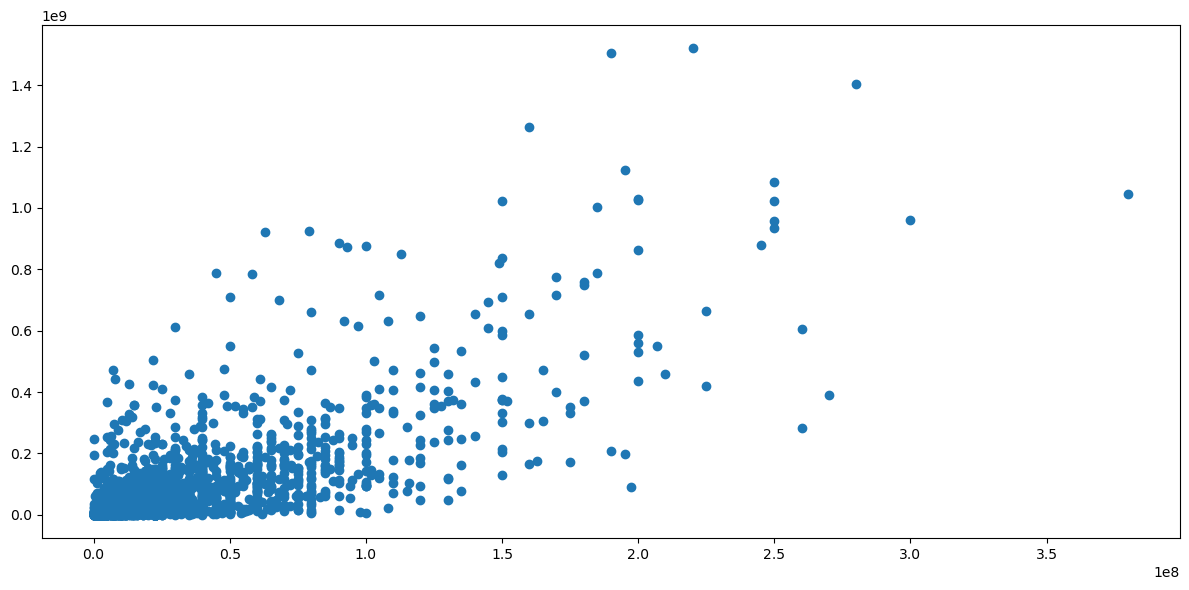

In [39]:
plt.figure(figsize=(12,6))
plt.scatter(train_df["budget"],train_df["revenue"])
plt.tight_layout()

In [40]:
genre_count = (train_df["genres"].apply(lambda x: [i["name"] for i in x]))
genre_count = Counter([j for i in genre_count for j in i])

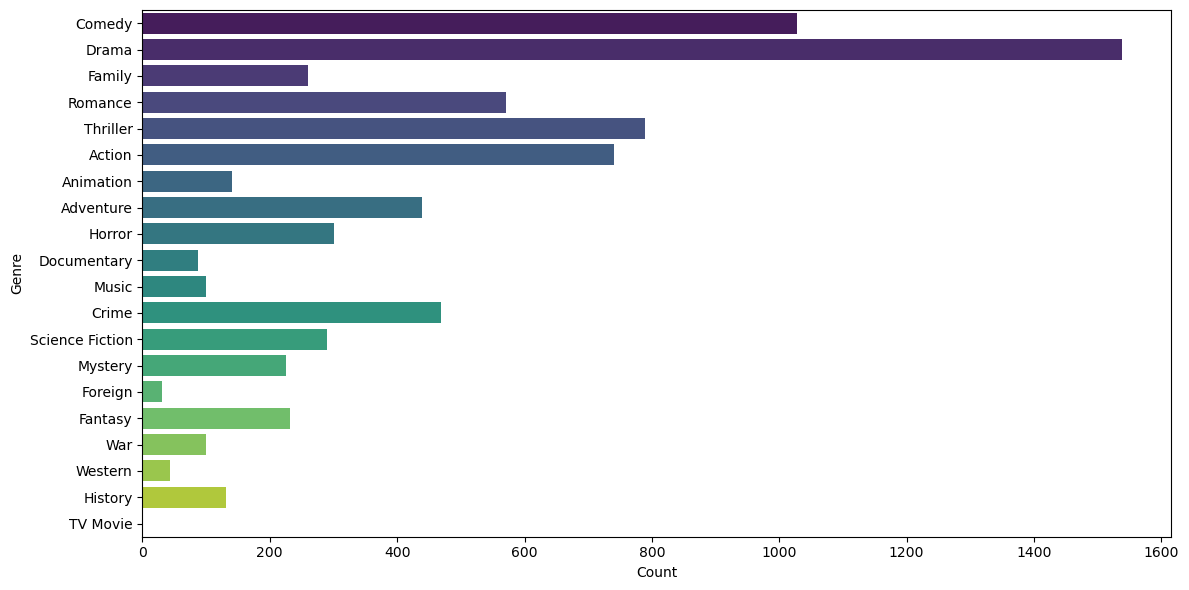

In [41]:
genre_count = dict(genre_count)
genre_df = pd.DataFrame({"Genre":genre_count.keys(),"Values":genre_count.values()})
plt.figure(figsize=(12,6))
sns.barplot(y=genre_df["Genre"],x=genre_df["Values"],palette="viridis")
plt.xlabel("Count")
plt.tight_layout()

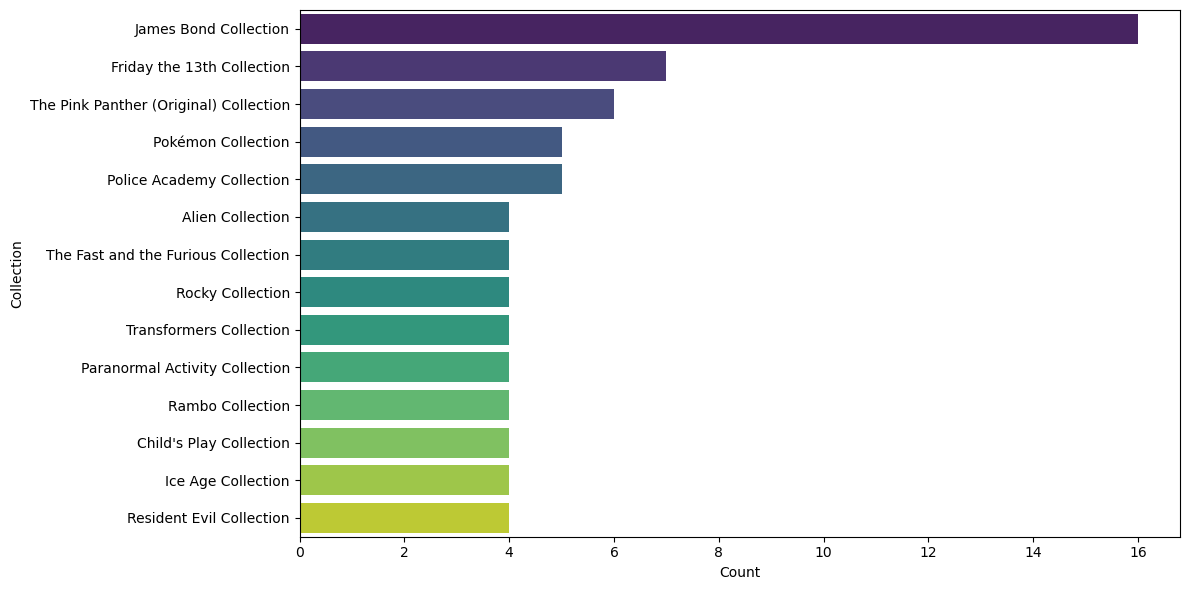

In [42]:
belongs_to_collection_df = train_df["belongs_to_collection"].value_counts()[:14].to_frame().reset_index()
plt.figure(figsize=(12,6))
sns.barplot(y=belongs_to_collection_df["index"],x=belongs_to_collection_df["belongs_to_collection"],palette="viridis")
plt.xlabel("Count")
plt.ylabel("Collection")
plt.tight_layout()

In [43]:
train_df["original_language"].value_counts()

en    2575
fr      78
ru      47
es      43
hi      42
ja      37
it      24
cn      20
ko      20
zh      19
de      18
ta      16
sv       8
nl       6
pt       6
fa       5
da       5
ro       4
hu       3
tr       3
no       2
ml       2
pl       2
te       2
fi       2
ur       1
he       1
el       1
ar       1
nb       1
vi       1
mr       1
cs       1
sr       1
bn       1
id       1
Name: original_language, dtype: int64

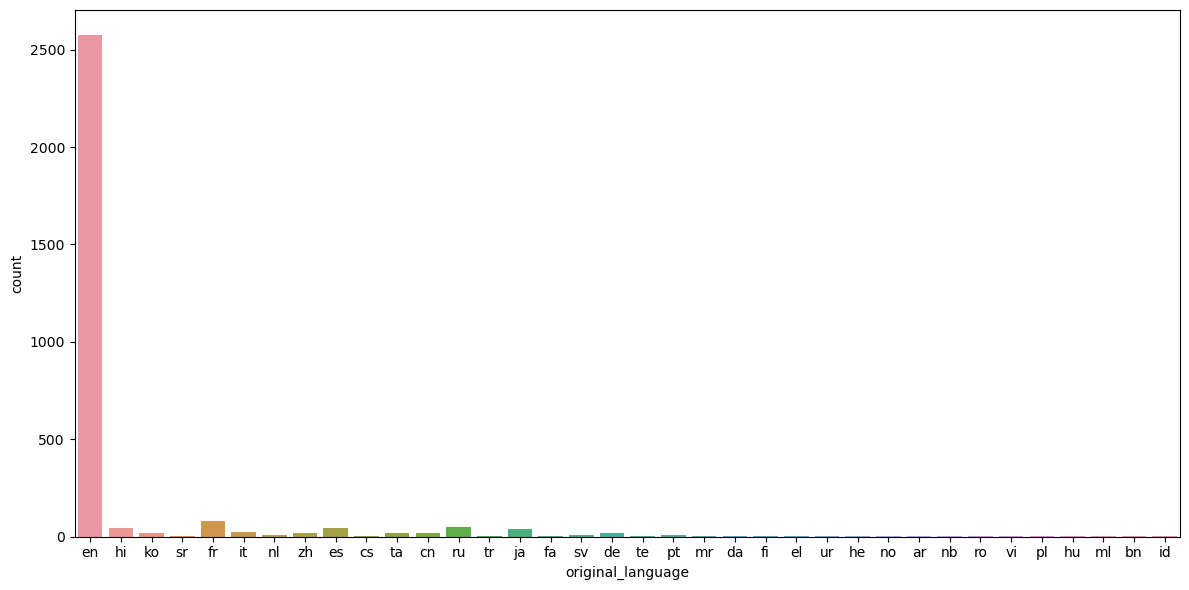

In [44]:
plt.figure(figsize=(12,6))
sns.countplot(x=train_df["original_language"])
plt.tight_layout()

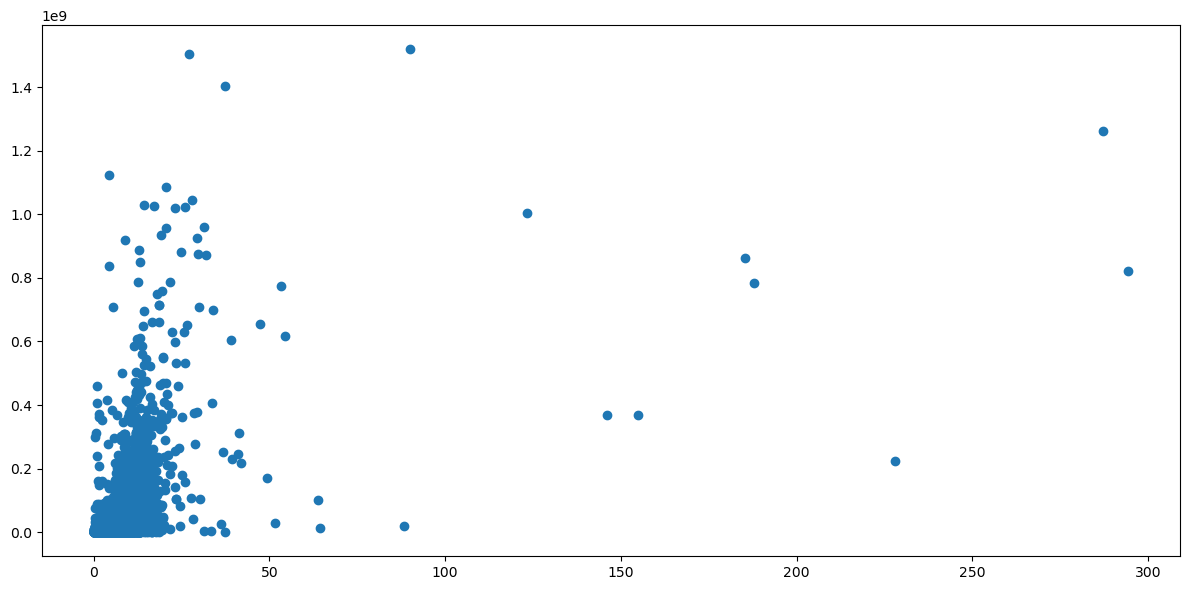

In [45]:
plt.figure(figsize=(12,6))
plt.scatter(train_df["popularity"],train_df["revenue"])
plt.tight_layout()

In [46]:
companies_count = (train_df["production_companies"].apply(lambda x: [i["name"] for i in x]))
companies_count = Counter([j for i in companies_count for j in i])
companies_count = companies_count.most_common()

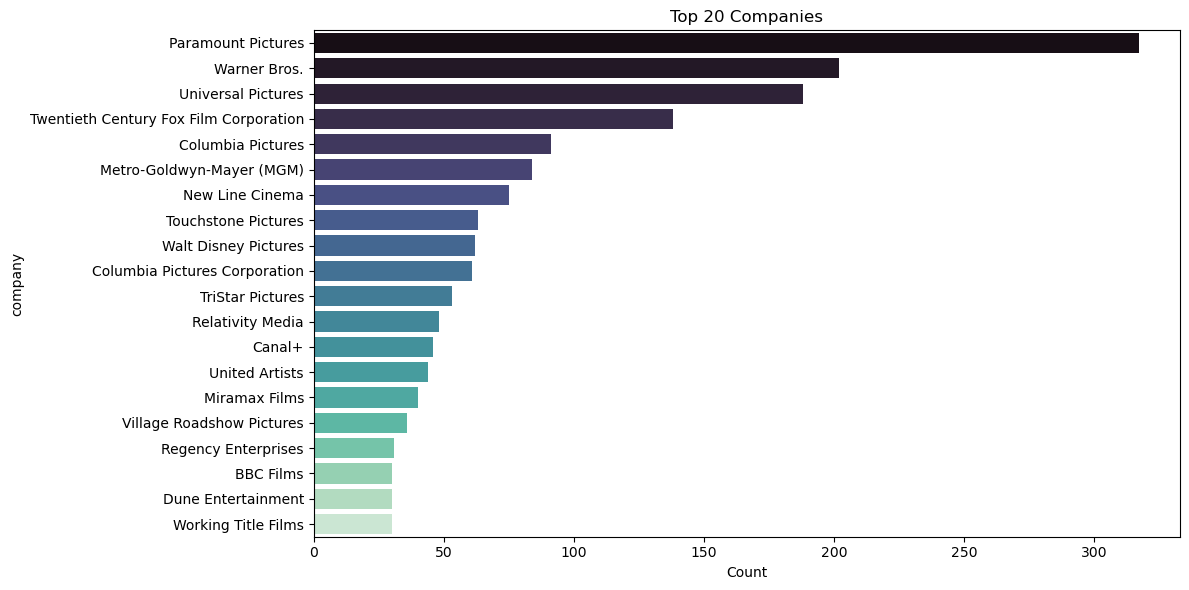

In [47]:
companies_count = dict(companies_count)
company_df = pd.DataFrame({"company":companies_count.keys(),"Values":companies_count.values()})
plt.figure(figsize=(12,6))
sns.barplot(y = company_df[:20]["company"],x = company_df[:20]["Values"],palette="mako")
plt.title("Top 20 Companies")
plt.xlabel("Count")
plt.tight_layout()

In [48]:
countries_count = (train_df["production_countries"].apply(lambda x: [i["name"] for i in x]))
countries_count = Counter([j for i in countries_count for j in i])
countries_count = countries_count.most_common()

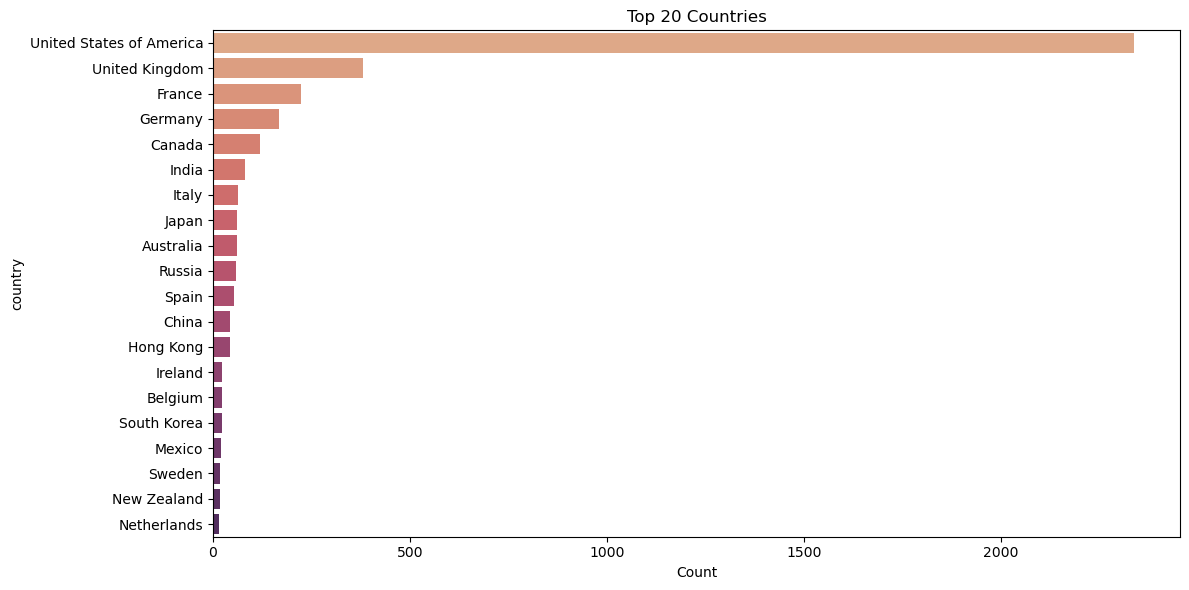

In [49]:
countries_count = dict(countries_count)
countries_df = pd.DataFrame({"country":countries_count.keys(),"Values":countries_count.values()})
plt.figure(figsize=(12,6))
sns.barplot(y = countries_df[:20]["country"],x = countries_df[:20]["Values"],palette="flare")
plt.title("Top 20 Countries")
plt.xlabel("Count")
plt.tight_layout()

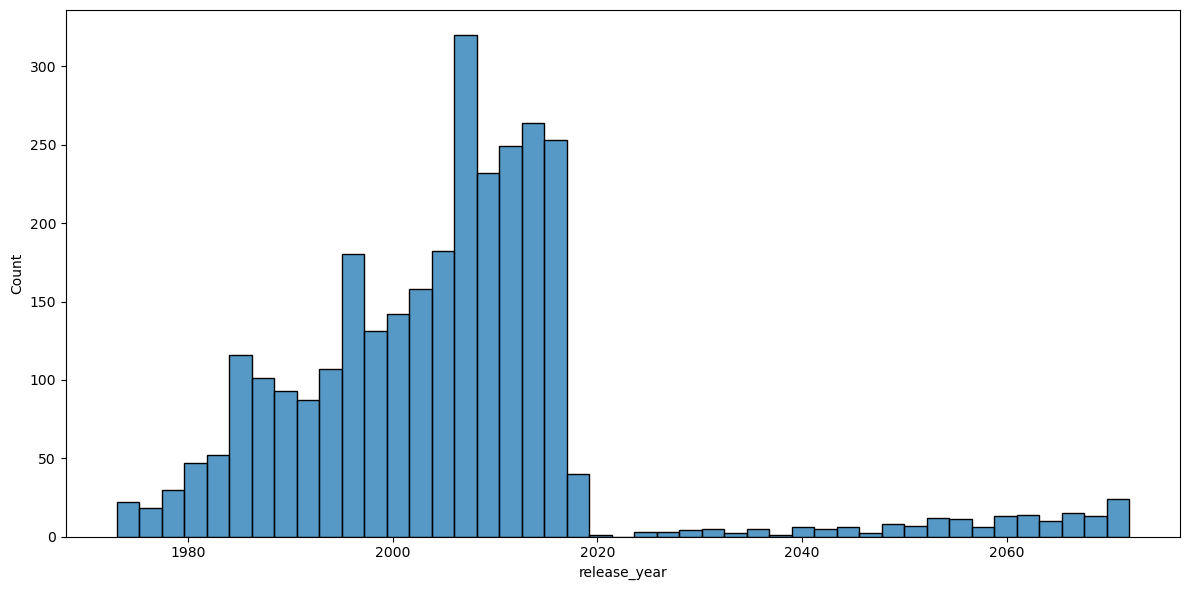

In [50]:
plt.figure(figsize=(12,6))
sns.histplot(x = train_df["release_year"])
plt.tight_layout()

In [51]:
languages_count = (train_df["spoken_languages"].apply(lambda x: [i["name"] for i in x]))
languages_count = Counter([j for i in languages_count for j in i])
languages_count = languages_count.most_common()
languages_count

[('English', 2638),
 ('Français', 288),
 ('Español', 239),
 ('Deutsch', 169),
 ('Pусский', 152),
 ('Italiano', 124),
 ('日本語', 89),
 ('普通话', 68),
 ('हिन्दी', 56),
 ('', 47),
 ('Português', 43),
 ('العربية', 40),
 ('한국어/조선말', 37),
 ('广州话 / 廣州話', 36),
 ('தமிழ்', 27),
 ('Polski', 25),
 ('Magyar', 24),
 ('Latin', 23),
 ('svenska', 22),
 ('ภาษาไทย', 22),
 ('Český', 20),
 ('עִבְרִית', 15),
 ('ελληνικά', 15),
 ('Türkçe', 13),
 ('Dansk', 13),
 ('Nederlands', 10),
 ('فارسی', 10),
 ('Tiếng Việt', 10),
 ('اردو', 8),
 ('Română', 8),
 ('తెలుగు', 7),
 ('Kiswahili', 7),
 ('Norsk', 7),
 ('No Language', 7),
 ('suomi', 6),
 ('Український', 6),
 ('Srpski', 4),
 ('Afrikaans', 4),
 ('Gaeilge', 3),
 ('Català', 3),
 ('বাংলা', 3),
 ('ਪੰਜਾਬੀ', 3),
 ('Somali', 3),
 ('Íslenska', 3),
 ('български език', 2),
 ('shqip', 2),
 ('Bahasa indonesia', 2),
 ('Slovenčina', 2),
 ('Esperanto', 2),
 ('euskera', 2),
 ('isiZulu', 2),
 ('Hrvatski', 2),
 ('қазақ', 1),
 ('Wolof', 1),
 ('Eesti', 1),
 ('پښتو', 1)]

In [52]:
train_df["status"].value_counts()

Released    2996
Rumored        4
Name: status, dtype: int64

In [53]:
Keywords_count = (train_df["Keywords"].apply(lambda x: [i["name"] for i in x]))
Keywords_count = Counter([j for i in Keywords_count for j in i])
Keywords_count = Keywords_count.most_common()

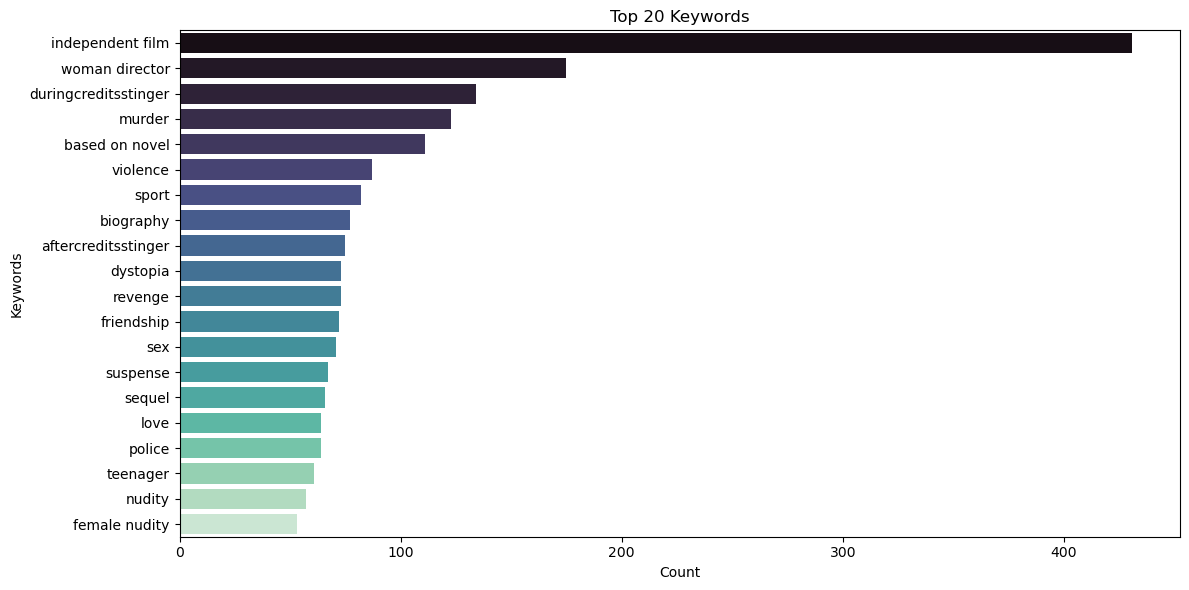

In [54]:
Keywords_count = dict(Keywords_count)
Keywords_df = pd.DataFrame({"Keywords":Keywords_count.keys(),"Values":Keywords_count.values()})
plt.figure(figsize=(12,6))
sns.barplot(y = Keywords_df[:20]["Keywords"],x = Keywords_df[:20]["Values"],palette="mako")
plt.title("Top 20 Keywords")
plt.xlabel("Count")
plt.tight_layout()

In [55]:
cast_count = (train_df["cast"].apply(lambda x: [i["name"] for i in x]))
cast_count = Counter([j for i in cast_count for j in i])
cast_count = cast_count.most_common()

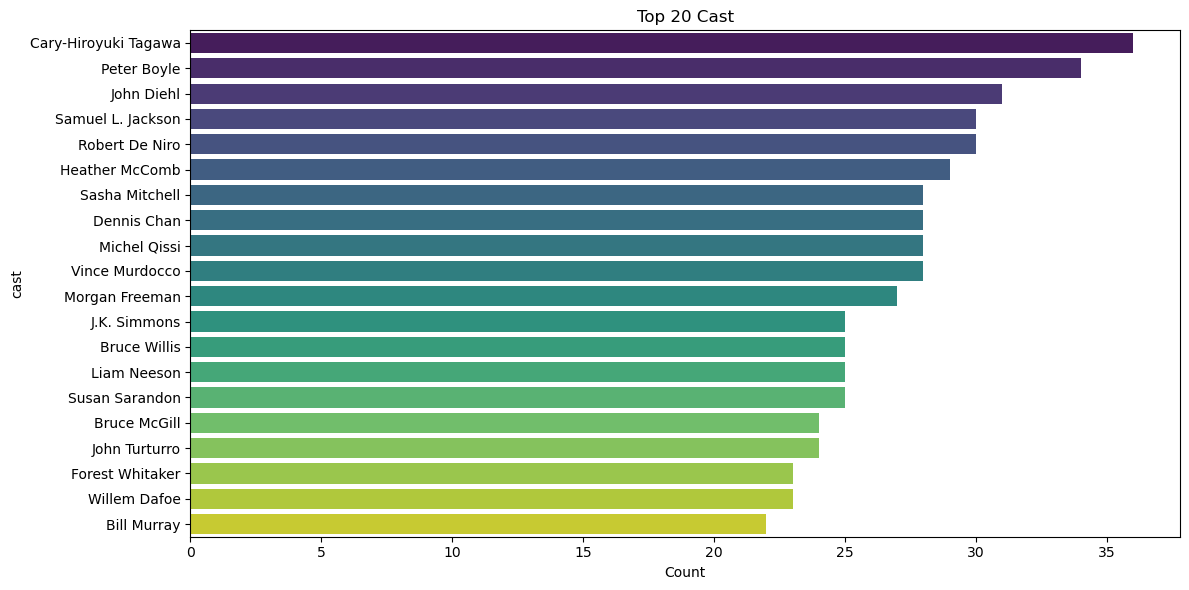

In [56]:
cast_count = dict(cast_count)
cast_df = pd.DataFrame({"cast":cast_count.keys(),"Values":cast_count.values()})
plt.figure(figsize=(12,6))
sns.barplot(y = cast_df[:20]["cast"],x = cast_df[:20]["Values"],palette="viridis")
plt.title("Top 20 Cast")
plt.xlabel("Count")
plt.tight_layout()

In [57]:
crew_count = (train_df["crew"].apply(lambda x: [i["name"] for i in x]))
crew_count = Counter([j for i in crew_count for j in i])
crew_count = crew_count.most_common()

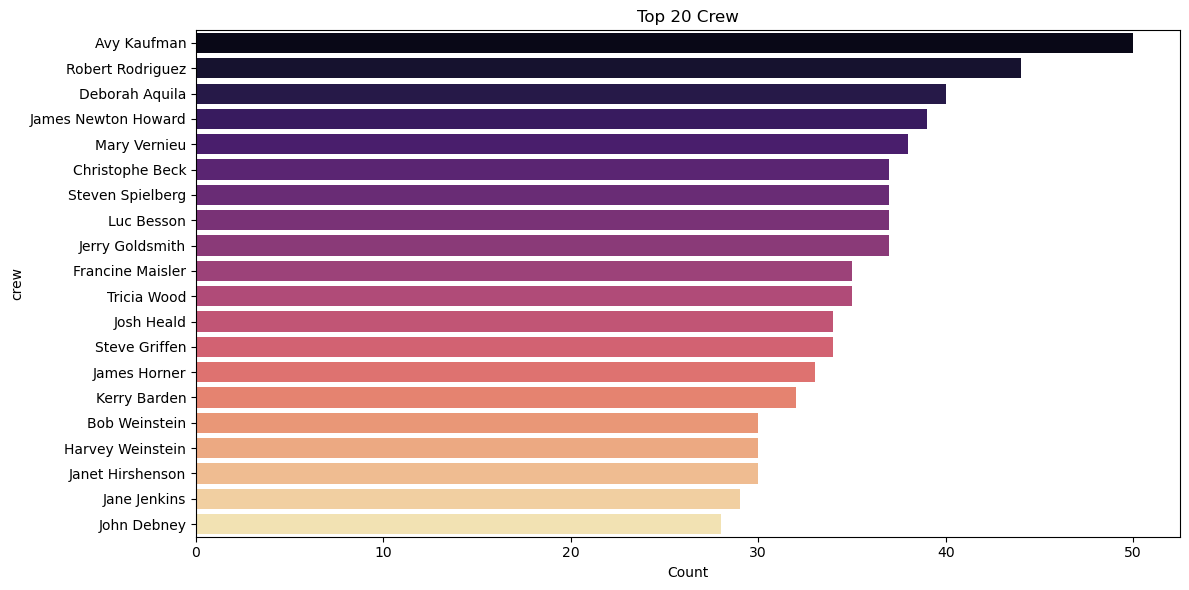

In [58]:
crew_count = dict(crew_count)
crew_df = pd.DataFrame({"crew":crew_count.keys(),"Values":crew_count.values()})
plt.figure(figsize=(12,6))
sns.barplot(y = crew_df[:20]["crew"],x = crew_df[:20]["Values"],palette="magma")
plt.title("Top 20 Crew")
plt.xlabel("Count")
plt.tight_layout()

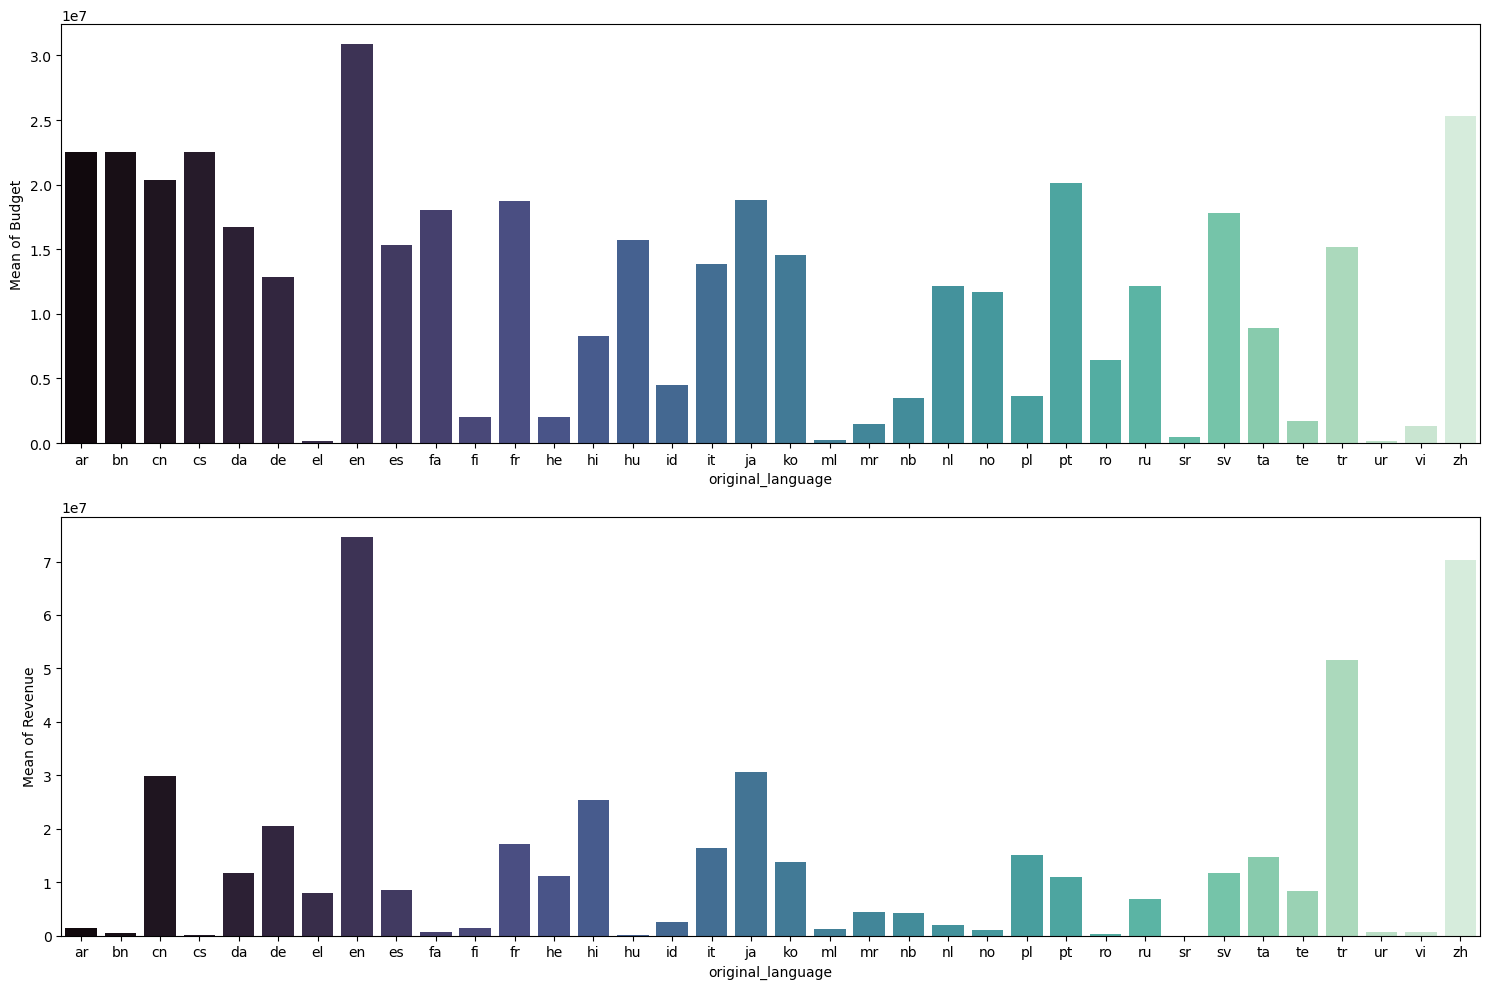

In [59]:
original_language_budget = train_df.groupby("original_language")[["budget","revenue"]].mean().reset_index()
fig , ax = plt.subplots(2,1,figsize = (15,10))
ax1 = sns.barplot(x=original_language_budget["original_language"],y=original_language_budget["budget"],ax=ax[0],palette="mako")
ax1.set_ylabel("Mean of Budget")
ax2 = sns.barplot(x=original_language_budget["original_language"],y=original_language_budget["revenue"],ax=ax[1],palette="mako")
ax2.set_ylabel("Mean of Revenue")
plt.tight_layout()

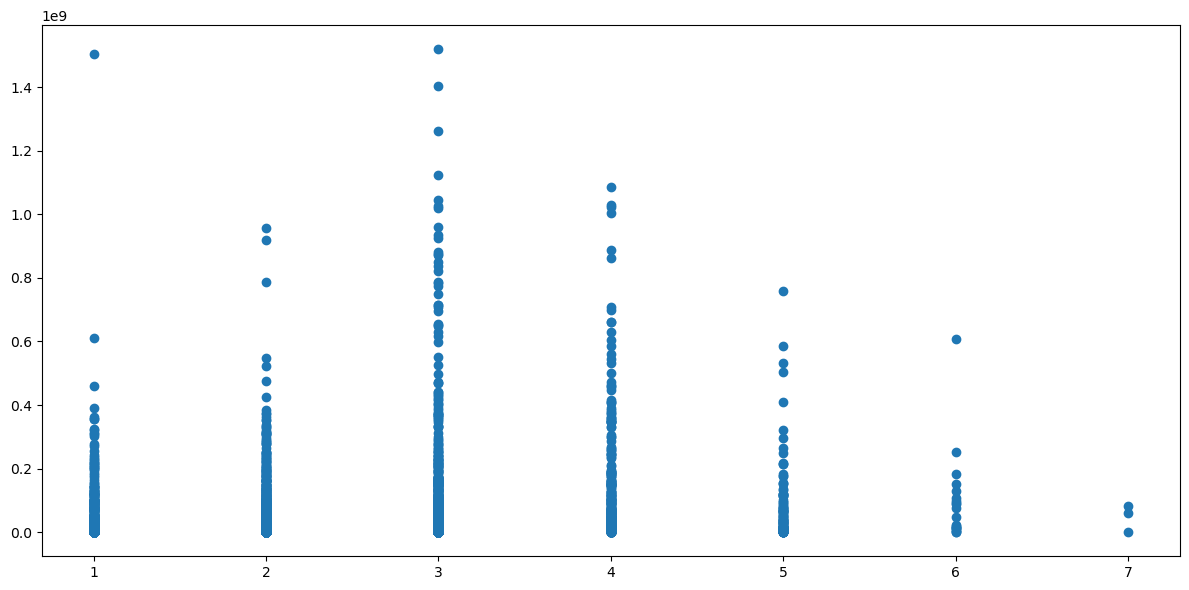

In [60]:
plt.figure(figsize=(12,6))
plt.scatter(train_df["genre_count"],train_df["revenue"])
plt.tight_layout()

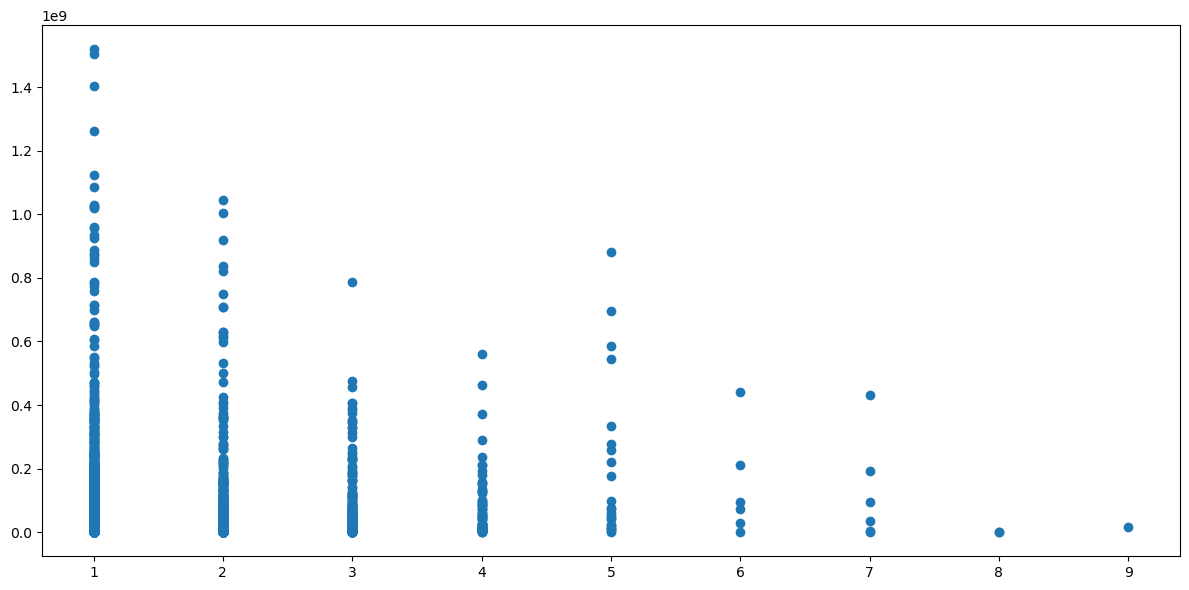

In [61]:
plt.figure(figsize=(12,6))
plt.scatter(train_df["languages_count"],train_df["revenue"])
plt.tight_layout()

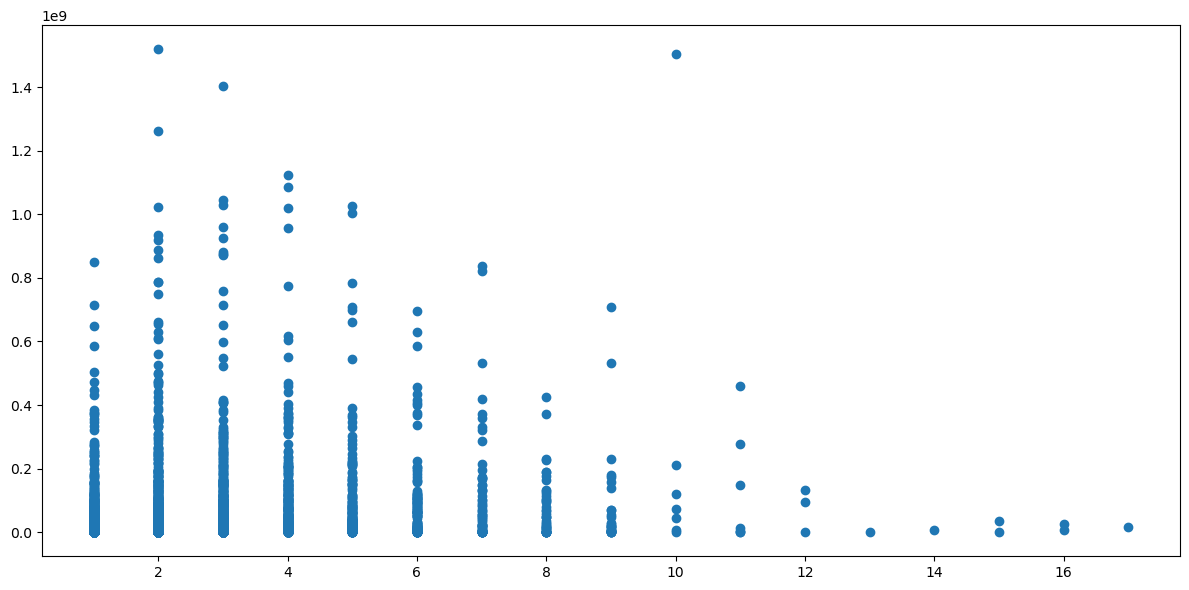

In [62]:
plt.figure(figsize=(12,6))
plt.scatter(train_df["companies_count"],train_df["revenue"])
plt.tight_layout()

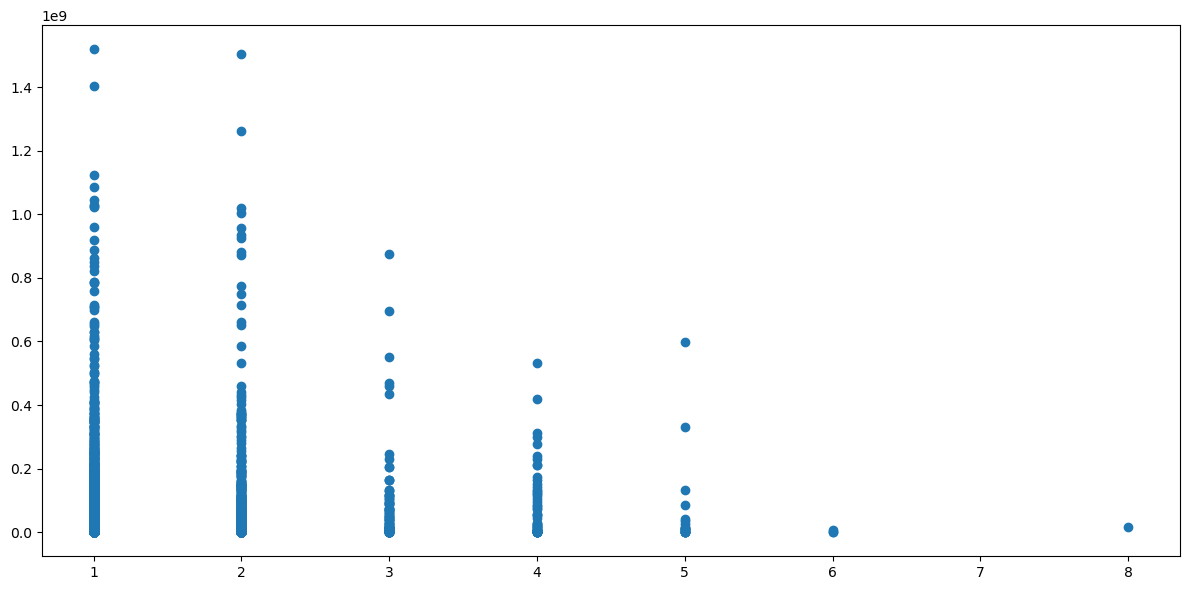

In [63]:
plt.figure(figsize=(12,6))
plt.scatter(train_df["countres_count"],train_df["revenue"])
plt.tight_layout()

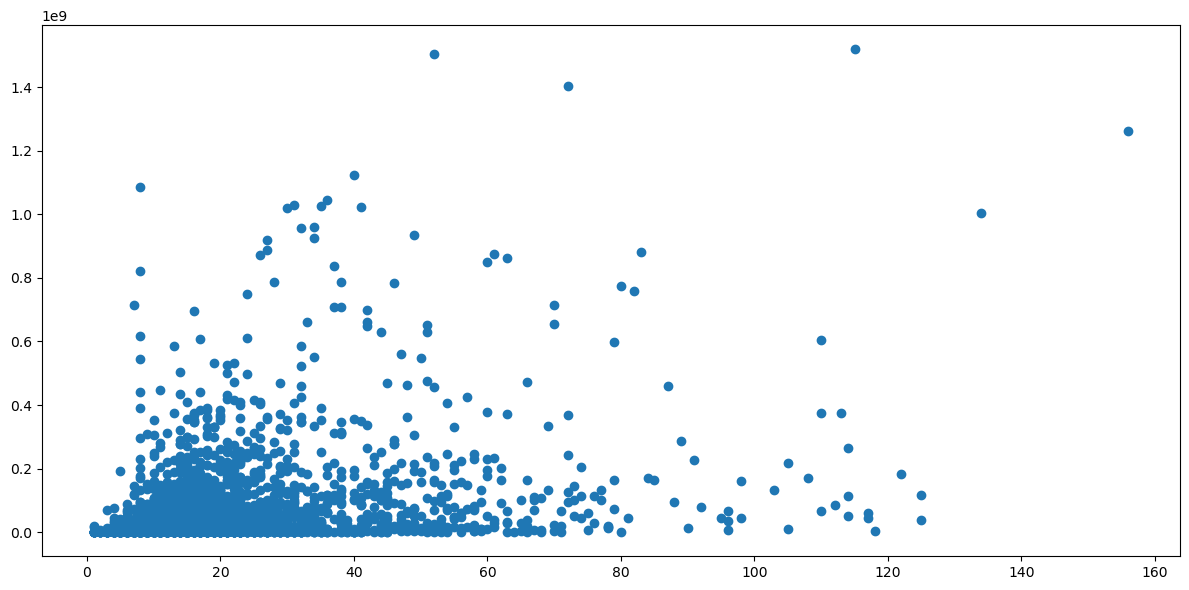

In [64]:
plt.figure(figsize=(12,6))
plt.scatter(train_df["cast_count"],train_df["revenue"])
plt.tight_layout()

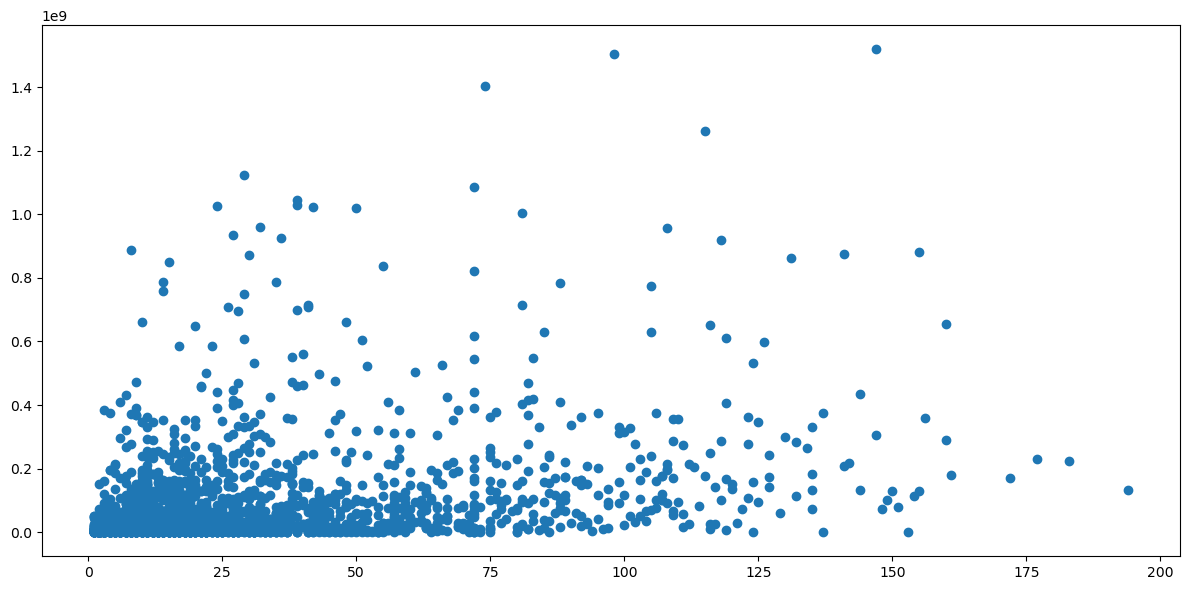

In [65]:
plt.figure(figsize=(12,6))
plt.scatter(train_df["crew_count"],train_df["revenue"])
plt.tight_layout()

<Figure size 1300x600 with 0 Axes>

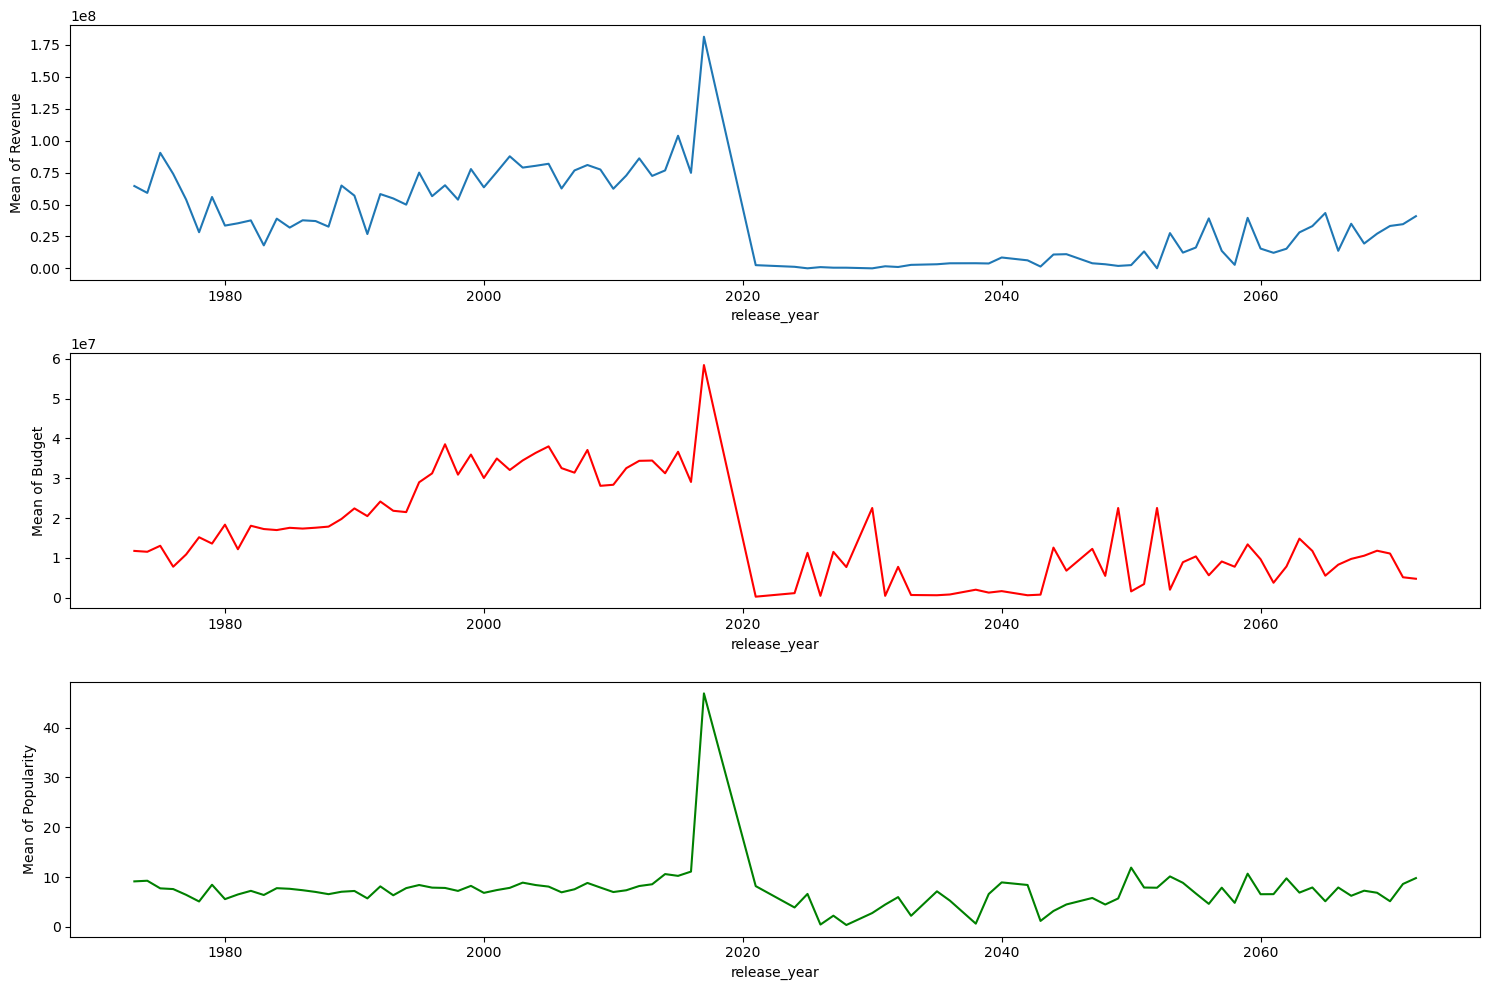

In [66]:
year_df = train_df.groupby("release_year")[["revenue","budget","popularity","runtime"]].mean().reset_index()
plt.figure(figsize=(13,6))
fig , ax = plt.subplots(3,1,figsize = (15,10))
ax1 = sns.lineplot(x=year_df["release_year"],y=year_df["revenue"],ax=ax[0])
ax1.set_ylabel("Mean of Revenue")
ax2 = sns.lineplot(x=year_df["release_year"],y=year_df["budget"],color="r",ax=ax[1])
ax2.set_ylabel("Mean of Budget")
ax3 = sns.lineplot(x=year_df["release_year"],y=year_df["popularity"],color="g",ax=ax[2])
ax3.set_ylabel("Mean of Popularity")
plt.tight_layout()

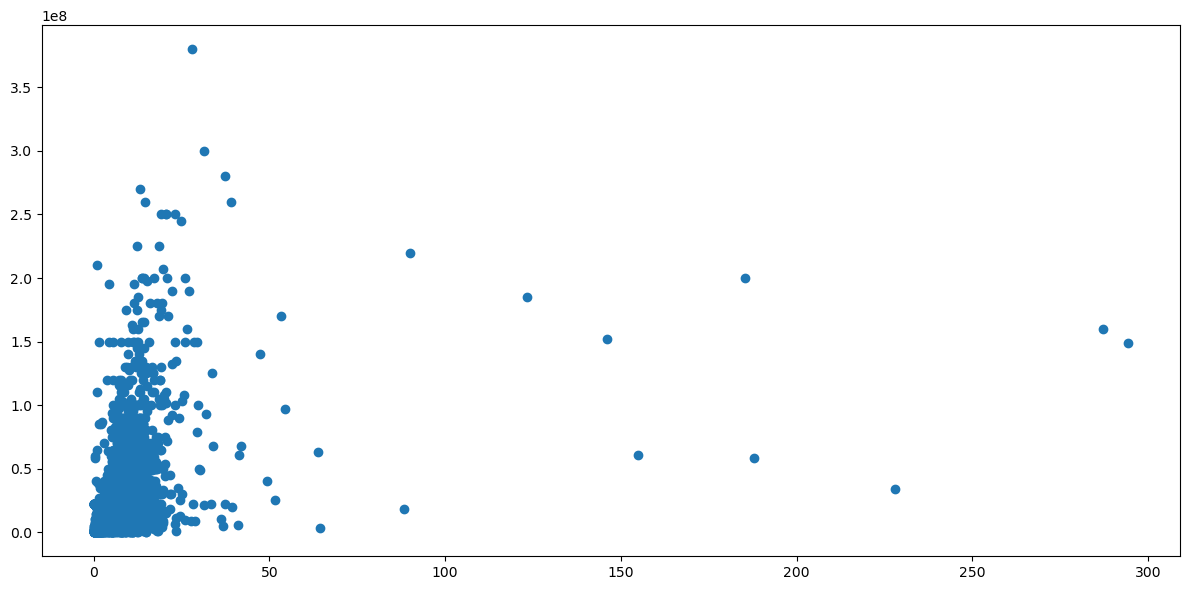

In [67]:
plt.figure(figsize=(12,6))
plt.scatter(train_df["popularity"],train_df["budget"])
plt.tight_layout()

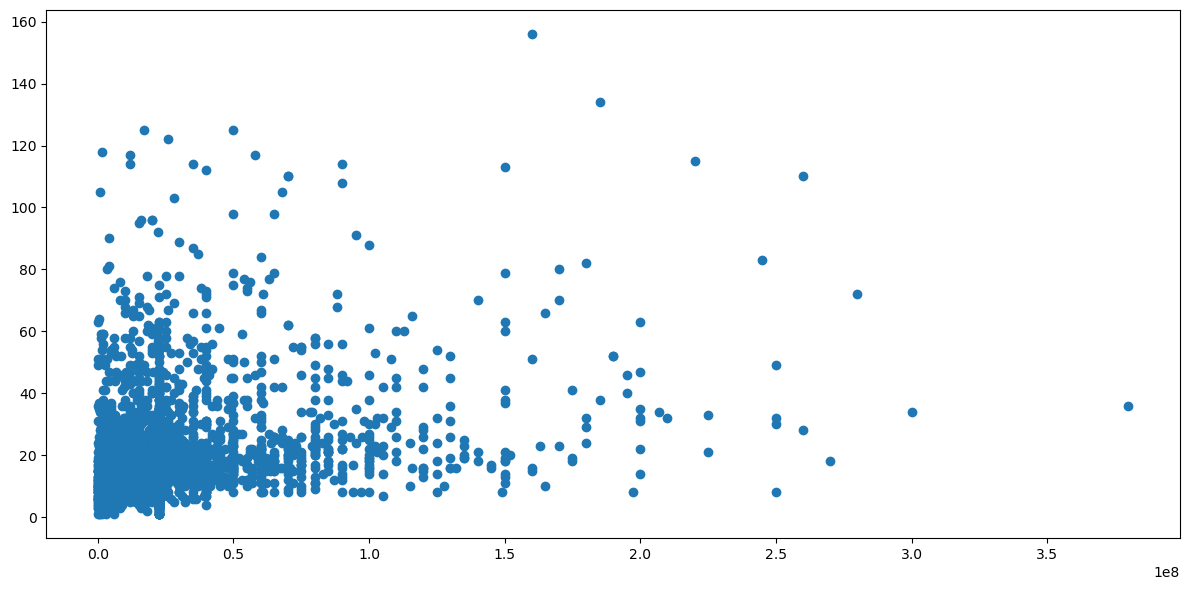

In [68]:
plt.figure(figsize=(12,6))
plt.scatter(train_df["budget"],train_df["cast_count"])
plt.tight_layout()

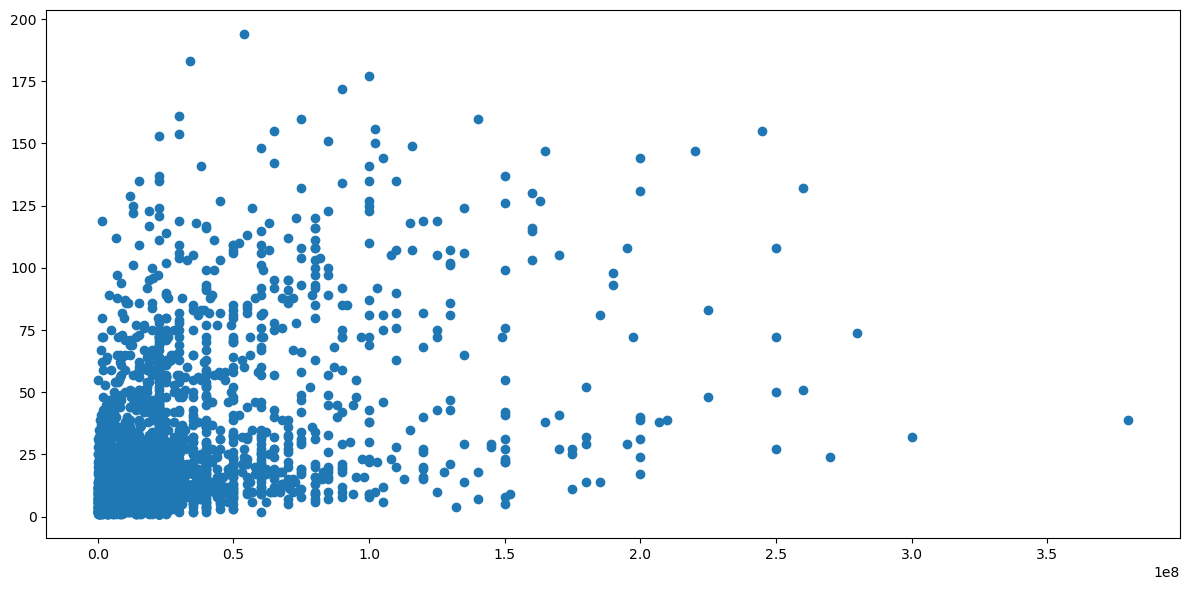

In [69]:
plt.figure(figsize=(12,6))
plt.scatter(train_df["budget"],train_df["crew_count"])
plt.tight_layout()

In [70]:
columns_to_drop=["all_genres","all_languages","all_countries","all_production_companies","id","belongs_to_collection","genres","homepage","imdb_id","status","original_title","overview","poster_path","production_companies","production_countries","release_date","spoken_languages","tagline","title","Keywords","cast","crew","release_day_name"]
train_df.drop(columns_to_drop,axis=1,inplace=True)

In [71]:
train_df.head()

,budget,original_language,popularity,runtime,revenue,genre_count,genre_Drama,genre_Comedy,genre_Thriller,genre_Action,genre_Romance,genre_Crime,genre_Adventure,genre_Horror,genre_Science Fiction,genre_Family,genre_Fantasy,genre_Mystery,genre_Animation,genre_History,genre_Music,companies_count,production_company_Paramount Pictures,production_company_Warner Bros.,production_company_Universal Pictures,production_company_Twentieth Century Fox Film Corporation,production_company_Columbia Pictures,production_company_Metro-Goldwyn-Mayer (MGM),production_company_New Line Cinema,production_company_Touchstone Pictures,production_company_Walt Disney Pictures,production_company_Columbia Pictures Corporation,production_company_TriStar Pictures,production_company_Relativity Media,production_company_Canal+,production_company_United Artists,production_company_Miramax Films,production_company_Village Roadshow Pictures,production_company_Regency Enterprises,production_company_BBC Films,production_company_Dune Entertainment,production_company_Working Title Films,production_company_Fox Searchlight Pictures,production_company_StudioCanal,production_company_Lionsgate,production_company_DreamWorks SKG,production_company_Fox 2000 Pictures,production_company_Summit Entertainment,production_company_Hollywood Pictures,production_company_Orion Pictures,production_company_Amblin Entertainment,production_company_Dimension Films,countres_count,production_country_United States of America,production_country_United Kingdom,production_country_France,production_country_Germany,production_country_Canada,production_country_India,production_country_Italy,production_country_Japan,production_country_Australia,production_country_Russia,production_country_Spain,production_country_China,production_country_Hong Kong,production_country_Ireland,production_country_Belgium,production_country_South Korea,production_country_Mexico,production_country_Sweden,production_country_New Zealand,production_country_Netherlands,production_country_Czech Republic,production_country_Denmark,production_country_Brazil,production_country_Luxembourg,production_country_South Africa,release_year,release_month,release_day,languages_count,language_English,language_Français,language_Español,language_Deutsch,language_Pусский,language_Italiano,language_日本語,language_普通话,language_हिन्दी,language_,language_Português,language_العربية,language_한국어/조선말,language_广州话 / 廣州話,language_தமிழ்,language_Polski,language_Magyar,language_Latin,language_svenska,language_ภาษาไทย,language_Český,language_עִבְרִית,language_ελληνικά,language_Türkçe,language_Dansk,language_Nederlands,language_فارسی,language_Tiếng Việt,language_اردو,language_Română,Keywords_count,cast_count,crew_count
0,14000000.00,en,6.575393,93.0,12314651,1,0,1,0,0,0,0,0,0,0,0,0,0,0,0,0,3,1,0,0,0,0,1,0,0,0,0,0,0,0,1,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,1,1,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,2015,2,20,1,1,0,0,0,0,0,0,0,0,1,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,4,24,72
1,40000000.00,en,8.248895,113.0,95149435,4,1,1,0,0,1,0,0,0,0,1,0,0,0,0,0,1,0,0,0,0,0,0,0,0,1,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,1,1,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,2004,8,6,1,1,0,0,0,0,0,0,0,0,1,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,4,20,9
2,3300000.00,en,64.299990,105.0,13092000,1,1,0,0,0,0,0,0,0,0,0,0,0,0,0,0,3,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,1,1,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,2014,10,10,1,1,0,0,0,0,0,0,0,0,1,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,12,51,64
3,1200000.00,hi,3.174936,122.0,16000000,2,1,0,1,0,0,0,0,0,0,0,0,0,0,0,0,1,1,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,1,0,0,0,0,0,1,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,2012,3,9,2,1,0,0,0,0,0,0,0,1,1,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,7,7,3
4,22531334.11,ko,1.148070,118.0,3923970,2,0,0,1,1,0,0,0,0,0,0,0,0,0,0,0,1,1,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,1,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,1,0,0,0,0,0,0,0,0,0,2009,2,5,1,0,0,0,

In [72]:
label = LabelEncoder()
train_df["original_language"] = label.fit_transform(train_df["original_language"])

In [73]:
train_df['budget_to_popularity'] = train_df['budget'] / train_df['popularity']
train_df['budget_to_runtime'] = train_df['budget'] / train_df['runtime']
###############
test_df['budget_to_popularity'] = test_df['budget'] / test_df['popularity']
test_df['budget_to_runtime'] = test_df['budget'] / test_df['runtime']

/tmp/ipykernel_21/3077001622.py:4: PerformanceWarning: DataFrame is highly fragmented.  This is usually the result of calling `frame.insert` many times, which has poor performance.  Consider joining all columns at once using pd.concat(axis=1) instead. To get a de-fragmented frame, use `newframe = frame.copy()`
  test_df['budget_to_popularity'] = test_df['budget'] / test_df['popularity']
/tmp/ipykernel_21/3077001622.py:5: PerformanceWarning: DataFrame is highly fragmented.  This is usually the result of calling `frame.insert` many times, which has poor performance.  Consider joining all columns at once using pd.concat(axis=1) instead. To get a de-fragmented frame, use `newframe = frame.copy()`
  test_df['budget_to_runtime'] = test_df['budget'] / test_df['runtime']


In [74]:
X = train_df.drop("revenue",axis=1)
Y = train_df["revenue"]

In [75]:
X_train, X_test, y_train, y_test = train_test_split(X,Y,test_size=0.3)

In [76]:
def RSE(y_true, y_predicted):
    y_true = np.array(y_true)
    y_predicted = np.array(y_predicted)
    RSS = np.sum(np.square(y_true - y_predicted))

    rse = sqrt(RSS / (len(y_true) - 2))
    return rse

In [77]:
models=[LinearRegression(),RandomForestRegressor(),SVR(),AdaBoostRegressor(),BaggingRegressor(),KNeighborsRegressor(),DecisionTreeRegressor()]
model_names=["LinearRegression","RandomForestRegressor","SVR","AdaBoostRegressor","BaggingRegressor","KNeighborsRegressor","DecisionTreeRegressor"]
MSE=[]
r_2=[]
RSE_ = []
accuracy = []
RMSE = []
d={}
for model in range (len(models)):
    model=models[model]
    model.fit(X_train,y_train)
    y_pre=model.predict(X_test)
    MSE.append(round(mean_squared_error(y_true=y_test,y_pred=y_pre),5))
    r_2.append(r2_score(y_true=y_test,y_pred=y_pre))
    RSE_.append(round(RSE(y_test,y_pre),5))
    accuracy.append((model.score(X_test,y_test))*100)
    RMSE.append(sqrt(mean_squared_error(y_true=y_test,y_pred=y_pre)))
d=pd.DataFrame({'Modelling Name':model_names,'MSE':MSE,"R_2":r_2,"RSE":RSE_,"Accuracy":accuracy,"RMSE":RMSE})


In [78]:
d

,Modelling Name,MSE,R_2,RSE,Accuracy,RMSE
0,LinearRegression,9.015270e+15,0.637998,9.505445e+07,63.799787,9.494878e+07
1,RandomForestRegressor,8.810166e+15,0.646234,9.396695e+07,64.623369,9.386249e+07
2,SVR,2.829519e+16,-0.136174,1.683990e+08,-13.617431,1.682117e+08
3,AdaBoostRegressor,1.978339e+16,0.205611,1.408100e+08,20.561144,1.406534e+08
4,BaggingRegressor,9.703963e+15,0.610344,9.861833e+07,61.034387,9.850870e+07
5,KNeighborsRegressor,1.218570e+16,0.510691,1.105117e+08,51.069131,1.103889e+08
6,DecisionTreeRegressor,1.290573e+16,0.481779,1.137298e+08,48.177904,1.136034e+08


In [79]:
model = RandomForestRegressor()
model.fit(X,Y)

RandomForestRegressor()

In [80]:
test_df.head()

,id,belongs_to_collection,budget,genres,homepage,imdb_id,original_language,original_title,overview,popularity,poster_path,production_companies,production_countries,release_date,runtime,spoken_languages,status,tagline,title,Keywords,cast,crew,genre_count,all_genres,genre_Drama,genre_Comedy,genre_Thriller,genre_Action,genre_Romance,genre_Crime,genre_Adventure,genre_Horror,genre_Science Fiction,genre_Family,genre_Fantasy,genre_Mystery,genre_Animation,genre_History,genre_Music,companies_count,all_production_companies,production_company_Paramount Pictures,production_company_Warner Bros.,production_company_Universal Pictures,production_company_Twentieth Century Fox Film Corporation,production_company_Columbia Pictures,production_company_Metro-Goldwyn-Mayer (MGM),production_company_New Line Cinema,production_company_Touchstone Pictures,production_company_Walt Disney Pictures,production_company_Columbia Pictures Corporation,production_company_TriStar Pictures,production_company_Relativity Media,production_company_Canal+,production_company_United Artists,production_company_Miramax Films,production_company_Village Roadshow Pictures,production_company_Regency Enterprises,production_company_BBC Films,production_company_Dune Entertainment,production_company_Working Title Films,production_company_Fox Searchlight Pictures,production_company_StudioCanal,production_company_Lionsgate,production_company_DreamWorks SKG,production_company_Fox 2000 Pictures,production_company_Summit Entertainment,production_company_Hollywood Pictures,production_company_Orion Pictures,production_company_Amblin Entertainment,production_company_Dimension Films,countres_count,all_countries,production_country_United States of America,production_country_United Kingdom,production_country_France,production_country_Germany,production_country_Canada,production_country_India,production_country_Italy,production_country_Japan,production_country_Australia,production_country_Russia,production_country_Spain,production_country_China,production_country_Hong Kong,production_country_Ireland,production_country_Belgium,production_country_South Korea,production_country_Mexico,production_country_Sweden,production_country_New Zealand,production_country_Netherlands,production_country_Czech Republic,production_country_Denmark,production_country_Brazil,production_country_Luxembourg,production_country_South Africa,release_year,release_month,release_day,release_day_name,languages_count,all_languages,language_English,language_Français,language_Español,language_Deutsch,language_Pусский,language_Italiano,language_日本語,language_普通话,language_हिन्दी,language_,language_Português,language_العربية,language_한국어/조선말,language_广州话 / 廣州話,language_தமிழ்,language_Polski,language_Magyar,language_Latin,language_svenska,language_ภาษาไทย,language_Český,language_עִבְרִית,language_ελληνικά,language_Türkçe,language_Dansk,language_Nederlands,language_فارسی,language_Tiếng Việt,language_اردو,language_Română,Keywords_count,cast_count,crew_count,budget_to_popularity,budget_to_runtime
0,3001,"[{'id': 34055, 'name': 'Pokémon Collection', '...",2.264929e+07,"[{'id': 12, 'name': 'Adventure'}, {'id': 16, '...",http://www.pokemon.com/us/movies/movie-pokemon...,tt1226251,ja,ディアルガVSパルキアVSダークライ,Ash and friends (this time accompanied by newc...,3.851534,/tnftmLMemPLduW6MRyZE0ZUD19z.jpg,"[{'name': 'Paramount Pictures', 'id': 4}]","[{'iso_3166_1': 'JP', 'name': 'Japan'}, {'iso_...",2007-07-14,90.0,"[{'iso_639_1': 'en', 'name': 'English'}, {'iso...",Released,Somewhere Between Time & Space... A Legend Is ...,Pokémon: The Rise of Darkrai,"[{'id': 11451, 'name': 'pok√©mon'}, {'id': 115...","[{'cast_id': 3, 'character': 'Tonio', 'credit_...","[{'credit_id': '52fe44e7c3a368484e03d683', 'de...",4,Adventure Animation Family Fantasy,0,0,0,0,0,0,1,0,0,1,1,0,1,0,0,1,Paramount Pictures,1,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,2,Japan United States of America,1,0,0,0,0,0,0,1,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,2007,7,14,Saturday,2

In [81]:
ids = test_df["id"]

In [82]:
test_df.drop(columns_to_drop,axis=1,inplace=True)

In [83]:
test_df["original_language"] = label.fit_transform(test_df["original_language"])

In [84]:
test_df.head()

,budget,original_language,popularity,runtime,genre_count,genre_Drama,genre_Comedy,genre_Thriller,genre_Action,genre_Romance,genre_Crime,genre_Adventure,genre_Horror,genre_Science Fiction,genre_Family,genre_Fantasy,genre_Mystery,genre_Animation,genre_History,genre_Music,companies_count,production_company_Paramount Pictures,production_company_Warner Bros.,production_company_Universal Pictures,production_company_Twentieth Century Fox Film Corporation,production_company_Columbia Pictures,production_company_Metro-Goldwyn-Mayer (MGM),production_company_New Line Cinema,production_company_Touchstone Pictures,production_company_Walt Disney Pictures,production_company_Columbia Pictures Corporation,production_company_TriStar Pictures,production_company_Relativity Media,production_company_Canal+,production_company_United Artists,production_company_Miramax Films,production_company_Village Roadshow Pictures,production_company_Regency Enterprises,production_company_BBC Films,production_company_Dune Entertainment,production_company_Working Title Films,production_company_Fox Searchlight Pictures,production_company_StudioCanal,production_company_Lionsgate,production_company_DreamWorks SKG,production_company_Fox 2000 Pictures,production_company_Summit Entertainment,production_company_Hollywood Pictures,production_company_Orion Pictures,production_company_Amblin Entertainment,production_company_Dimension Films,countres_count,production_country_United States of America,production_country_United Kingdom,production_country_France,production_country_Germany,production_country_Canada,production_country_India,production_country_Italy,production_country_Japan,production_country_Australia,production_country_Russia,production_country_Spain,production_country_China,production_country_Hong Kong,production_country_Ireland,production_country_Belgium,production_country_South Korea,production_country_Mexico,production_country_Sweden,production_country_New Zealand,production_country_Netherlands,production_country_Czech Republic,production_country_Denmark,production_country_Brazil,production_country_Luxembourg,production_country_South Africa,release_year,release_month,release_day,languages_count,language_English,language_Français,language_Español,language_Deutsch,language_Pусский,language_Italiano,language_日本語,language_普通话,language_हिन्दी,language_,language_Português,language_العربية,language_한국어/조선말,language_广州话 / 廣州話,language_தமிழ்,language_Polski,language_Magyar,language_Latin,language_svenska,language_ภาษาไทย,language_Český,language_עִבְרִית,language_ελληνικά,language_Türkçe,language_Dansk,language_Nederlands,language_فارسی,language_Tiếng Việt,language_اردو,language_Română,Keywords_count,cast_count,crew_count,budget_to_popularity,budget_to_runtime
0,2.264929e+07,19,3.851534,90.0,4,0,0,0,0,0,0,1,0,0,1,1,0,1,0,0,1,1,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,2,1,0,0,0,0,0,0,1,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,2007,7,14,2,1,0,0,0,0,0,1,0,0,1,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,2,7,2,5.880590e+06,251658.790193
1,8.800000e+04,9,3.559789,65.0,2,0,0,0,0,0,0,0,1,1,0,0,0,0,0,0,1,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,1,1,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,2058,5,19,1,1,0,0,0,0,0,0,0,0,1,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,8,10,8,2.472057e+04,1353.846154
2,2.264929e+07,9,8.085194,100.0,2,0,1,0,0,1,0,0,0,0,0,0,0,0,0,0,3,0,1,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,1,1,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,1997,5,23,1,1,0,0,0,0,0,0,0,0,1,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,4,9,10,2.801329e+06,226492.911173
3,6.800000e+06,12,8.596012,130.0,3,1,0,0,0,0,0,0,0,0,0,0,1,0,0,0,3,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,2,0,0,1,0,1,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,2010,9,4,3,1,1,0,0,0,0,0,0,0,1,0,1,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,15,23,69,7.910645e+05,52307.692308
4,2.000000e+06,9,3.217680,92.0,2,0,0,0,0,0,0,0,0,0,0,0,0,0,1,0,1,1,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0

In [85]:
Prediction = model.predict(test_df)

In [86]:
Predictions = pd.DataFrame({"id":ids,"revenue":Prediction})

In [87]:
Predictions

,id,revenue
0,3001,1.938938e+07
1,3002,6.512902e+06
2,3003,1.476111e+07
3,3004,2.847482e+07
4,3005,3.409902e+06
...,...,...
4393,7394,1.014888e+08
4394,7395,5.695264e+07
4395,7396,3.567355e+07
4396,7397,1.751935e+08


In [88]:
Predictions.to_csv("submission.csv",index=False)